# ORAS5 + ERA5 ConvLSTM: cached tensor, 5-year forecast and full evaluation

This notebook:

1. Builds the combined monthly ORAS5/ERA5 tensor once and saves it as a compressed NetCDF file.
2. Loads the cached tensor on later runs to avoid repeated subsetting and regridding.
3. Trains a one-step-ahead ConvLSTM using data available before 1982.
4. Produces a recursive forecast for January 1982–December 1986.
5. Recreates the main ConvLSTM evaluation plots used in Shreya's report adapted to the North Atlantic study region.
6. Adds forecast-horizon, spatial-error, residual, persistence-baseline and per-variable diagnostics.

`REBUILD_COMBINED = True` to rebuild tensor

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import gc
import json
import pickle

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from scipy.interpolate import griddata
from scipy.stats import pearsonr

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Visible GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
Visible GPUs: []


In [2]:
#Config

DATA_ROOT = Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets")
ORAS5_DIR = DATA_ROOT / "ORAS5" / "BOXED"
ERA5_DIR = DATA_ROOT / "ERA5"

ERA5_FILES = {
    "era5_sst": ERA5_DIR / "sst.nc",
    "era5_u10": ERA5_DIR / "u10_v10.nc",
    "era5_v10": ERA5_DIR / "u10_v10.nc",
    "era5_runoff": ERA5_DIR / "runoff_full.nc",
    "era5_d2m": ERA5_DIR / "all_others.nc",
    "era5_skt": ERA5_DIR / "all_others.nc",
    "era5_stl2": ERA5_DIR / "all_others.nc",
    "era5_swvl1": ERA5_DIR / "all_others.nc",
}

ERA5_VAR_NAMES = {
    "era5_sst": "sst",
    "era5_u10": "u10",
    "era5_v10": "v10",
    "era5_runoff": "ro",
    "era5_d2m": "d2m",
    "era5_skt": "skt",
    "era5_stl2": "stl2",
    "era5_swvl1": "swvl1",
}

ORAS5_VAR_META = {
    "sst": {
        "token": "sst",
        "depth_mode": None,
    },
    "salinity": {
        "token": "so_salinity",
        "depth_mode": "0_100m",
    },
    "thetao": {
        "token": "thetao",
        "depth_mode": "0_100m",
    },
    "qnet": {
        "token": "heat",
        "depth_mode": None,
    },
    "u_current": {
        "token": "u_zonal",
        "depth_mode": "0_100m",
    },
    "v_current": {
        "token": "v_meridional",
        "depth_mode": "0_100m",
    },
}

REGION = {
    "lat_min": 25.0,
    "lat_max": 45.0,
    "lon_min": -50.0,
    "lon_max": -30.0,
}

DLAT = 0.5
DLON = 0.5
LOOKBACK = 12

FORECAST_START = pd.Timestamp("1982-01-01")
FORECAST_END = pd.Timestamp("1986-12-01")
VALIDATION_START = pd.Timestamp("1977-01-01")

EPOCHS = 50 # 25 maybe not enough
BATCH_SIZE = 4
LEARNING_RATE = 1e-3

CACHE_DIR = DATA_ROOT / "Processed"
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def coordinate_label(value, positive_letter, negative_letter):
    direction = positive_letter if value >= 0 else negative_letter
    number = f"{abs(value):g}".replace(".", "p")
    return f"{number}{direction}"


lat_min_label = coordinate_label(
    REGION["lat_min"],
    positive_letter="N",
    negative_letter="S",
)

lat_max_label = coordinate_label(
    REGION["lat_max"],
    positive_letter="N",
    negative_letter="S",
)

lon_min_label = coordinate_label(
    REGION["lon_min"],
    positive_letter="E",
    negative_letter="W",
)

lon_max_label = coordinate_label(
    REGION["lon_max"],
    positive_letter="E",
    negative_letter="W",
)

grid_label = f"{DLAT:g}".replace(".", "p")

COMBINED_CACHE = CACHE_DIR / (
    f"oras5_era5_monthly_"
    f"{lat_min_label}_{lat_max_label}_"
    f"{lon_min_label}_{lon_max_label}_"
    f"{grid_label}deg.nc"
)

SCALER_PATH = CACHE_DIR / (
    f"oras5_era5_convlstm_scaler_"
    f"{lat_min_label}_{lat_max_label}_"
    f"{lon_min_label}_{lon_max_label}.pkl"
)

MODEL_PATH = CACHE_DIR / (
    f"best_oras5_era5_convlstm_"
    f"{lat_min_label}_{lat_max_label}_"
    f"{lon_min_label}_{lon_max_label}.keras"
)

HISTORY_PATH = CACHE_DIR / (
    f"oras5_era5_training_history_"
    f"{lat_min_label}_{lat_max_label}_"
    f"{lon_min_label}_{lon_max_label}.json"
)

# Set True whenever:
# 1. REGION is changed;
# 2. raw data are changed;
# 3. loading/regridding code is changed.
REBUILD_COMBINED = True

FILE_RE = re.compile(
    r"ORAS5_(\d{4})_(\d{2})_(.+?)_boxed\.nc$"
)

print("Region:", REGION)
print("Combined tensor cache:", COMBINED_CACHE)
print("Rebuild requested:", REBUILD_COMBINED)

Region: {'lat_min': 25.0, 'lat_max': 45.0, 'lon_min': -50.0, 'lon_max': -30.0}
Combined tensor cache: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\oras5_era5_monthly_25N_45N_50W_30W_0p5deg.nc
Rebuild requested: True


In [3]:
# Data loading/regridding helpers

def open_nc(path):
    path = Path(path)
    errors = []
    for engine in ("h5netcdf", "netcdf4", "scipy"):
        try:
            return xr.open_dataset(path, engine=engine)
        except Exception as exc:
            errors.append(f"{engine}: {exc}")
    raise OSError(f"Could not open {path}\n" + "\n".join(errors))


def files_for_token(data_dir, token):
    paths = []
    for path in Path(data_dir).rglob("*.nc"):
        if FILE_RE.search(path.name) and token in path.name:
            paths.append(path)
    return sorted(paths)


def time_from_filename(path):
    match = FILE_RE.search(Path(path).name)
    if match is None:
        raise ValueError(f"Unexpected ORAS5 filename: {Path(path).name}")
    return pd.Timestamp(int(match.group(1)), int(match.group(2)), 1)


def find_main_var(ds):
    ignore = {
        "time", "time_counter", "valid_time", "nav_time",
        "lat", "lon", "latitude", "longitude", "nav_lat", "nav_lon",
        "depth", "deptht", "depthu", "depthv", "nav_lev",
        "bnds", "bounds", "nbnds", "nv"
    }
    candidates = [name for name in ds.data_vars if name not in ignore]
    if not candidates:
        raise ValueError(f"No usable data variable. data_vars={list(ds.data_vars)}")
    return candidates[0]


def normalise_longitude(lon):
    return xr.where(lon > 180, lon - 360, lon)


def clean_numeric_array(da):
    # Decode masked/fill values before casting.
    da = da.where(np.isfinite(da))
    fill_value = da.attrs.get("_FillValue", None)
    missing_value = da.attrs.get("missing_value", None)

    if fill_value is not None:
        da = da.where(da != fill_value)
    if missing_value is not None:
        da = da.where(da != missing_value)

    # Values of order 1e18 seen in the original notebook are encoded missing data.
    da = da.where(np.abs(da) < 1e10)

    for tdim in ("time_counter", "valid_time", "nav_time", "time"):
        if tdim in da.dims and da.sizes[tdim] == 1:
            da = da.isel({tdim: 0}, drop=True)

    for bdim in ("bnds", "bounds", "nbnds", "nv"):
        if bdim in da.dims:
            da = da.isel({bdim: 0}, drop=True)

    da = da.squeeze(drop=True)

    if "y" in da.dims and "x" in da.dims:
        da = da.transpose("y", "x")

    return da.astype(np.float32)


def depth_reduce_if_needed(da, ds, depth_mode):
    if depth_mode is None:
        return da

    for zname in ("depth", "deptht", "depthu", "depthv", "nav_lev"):
        if zname not in da.dims:
            continue

        if zname in da.coords:
            z = da[zname]
        elif zname in ds.coords:
            z = ds[zname]
        elif zname in ds.variables:
            z = ds[zname]
        else:
            z = xr.DataArray(np.arange(da.sizes[zname]), dims=[zname])

        if depth_mode == "0_100m":
            selected = da.where((z >= 0) & (z <= 100), drop=True)
            if selected.sizes.get(zname, 0) == 0:
                raise ValueError(f"No depth levels between 0 and 100 m in {zname}")
            return selected.mean(dim=zname, skipna=True)

    return da


def obtain_nav_coordinates(da, ds):
    lat_candidates = ("nav_lat", "latitude", "lat")
    lon_candidates = ("nav_lon", "longitude", "lon")

    nav_lat = None
    nav_lon = None

    for name in lat_candidates:
        if name in da.coords:
            nav_lat = da[name].values
            break
        if name in ds.variables:
            nav_lat = ds[name].values
            break

    for name in lon_candidates:
        if name in da.coords:
            nav_lon = da[name].values
            break
        if name in ds.variables:
            nav_lon = ds[name].values
            break

    if nav_lat is None or nav_lon is None:
        raise ValueError("No usable latitude/longitude coordinates found")

    return np.squeeze(nav_lat), np.squeeze(nav_lon)


def regrid_oras5_to_regular(da, ds, region, dlat=0.5, dlon=0.5):
    nav_lat, nav_lon = obtain_nav_coordinates(da, ds)
    nav_lon = np.where(nav_lon > 180, nav_lon - 360, nav_lon)

    values = np.squeeze(da.values).astype(np.float32)

    # Handle 1D regular coordinates as well as 2D curvilinear coordinates
    if nav_lat.ndim == 1 and nav_lon.ndim == 1:
        nav_lon, nav_lat = np.meshgrid(nav_lon, nav_lat)

    if values.shape != nav_lat.shape:
        if values.T.shape == nav_lat.shape:
            values = values.T
        else:
            raise ValueError(
                f"Grid mismatch: values={values.shape}, coordinates={nav_lat.shape}"
            )

    valid = (
        np.isfinite(values)
        & np.isfinite(nav_lat)
        & np.isfinite(nav_lon)
        & (np.abs(values) < 1e10)
        & (nav_lat >= region["lat_min"] - 1)
        & (nav_lat <= region["lat_max"] + 1)
        & (nav_lon >= region["lon_min"] - 1)
        & (nav_lon <= region["lon_max"] + 1)
    )

    if valid.sum() < 4:
        raise ValueError(f"Only {valid.sum()} valid source grid points")

    target_lats = np.arange(region["lat_min"], region["lat_max"] + dlat / 2, dlat)
    target_lons = np.arange(region["lon_min"], region["lon_max"] + dlon / 2, dlon)
    lon2d, lat2d = np.meshgrid(target_lons, target_lats)

    points = np.column_stack((nav_lon[valid], nav_lat[valid]))
    source_values = values[valid]

    linear = griddata(points, source_values, (lon2d, lat2d), method="linear")
    nearest = griddata(points, source_values, (lon2d, lat2d), method="nearest")
    result = np.where(np.isfinite(linear), linear, nearest)

    return xr.DataArray(
        result.astype(np.float32),
        dims=("lat", "lon"),
        coords={"lat": target_lats, "lon": target_lons},
        name=da.name,
    )


def standardise_era5_time(ds):
    if "valid_time" in ds.coords:
        ds = ds.rename({"valid_time": "time"})
    elif "time_counter" in ds.coords:
        ds = ds.rename({"time_counter": "time"})

    if "time" not in ds.coords:
        raise ValueError(f"No time coordinate. coords={list(ds.coords)}")

    ds = ds.assign_coords(time=pd.to_datetime(ds.time.values))
    return ds


def load_era5_variable(path, var_name, feature_name, region):
    with open_nc(path) as ds:
        ds = standardise_era5_time(ds)

        rename = {}
        if "latitude" in ds.coords:
            rename["latitude"] = "lat"
        if "longitude" in ds.coords:
            rename["longitude"] = "lon"
        if rename:
            ds = ds.rename(rename)

        if var_name not in ds.data_vars:
            raise ValueError(
                f"'{var_name}' not found in {Path(path).name}; "
                f"available={list(ds.data_vars)}"
            )

        da = ds[var_name]

        if "lon" in da.coords:
            da = da.assign_coords(lon=normalise_longitude(da.lon)).sortby("lon")
        if "lat" in da.coords:
            da = da.sortby("lat")

        da = da.sel(
            lat=slice(region["lat_min"], region["lat_max"]),
            lon=slice(region["lon_min"], region["lon_max"]),
        )

        for dim in list(da.dims):
            if dim not in ("time", "lat", "lon"):
                da = da.isel({dim: 0}, drop=True)

        da = da.where(np.abs(da) < 1e10)
        da = da.resample(time="MS").mean(skipna=True)

        # Convert ERA5 temperatures from K to degrees C
        if feature_name in ("era5_sst", "era5_d2m", "era5_skt", "era5_stl2"):
            da = da - 273.15

        target_lats = np.arange(
            region["lat_min"], region["lat_max"] + DLAT / 2, DLAT
        )
        target_lons = np.arange(
            region["lon_min"], region["lon_max"] + DLON / 2, DLON
        )

        da = da.interp(lat=target_lats, lon=target_lons)
        da = da.astype(np.float32)
        da.name = feature_name

        return da.load()


print("Helper functions ready.")

Helper functions ready.


In [4]:
# Build/load combined tensor

def build_combined_monthly_tensor():
    print("Indexing ORAS5 files...")

    file_dict = {}

    for feature_name, meta in ORAS5_VAR_META.items():
        paths = files_for_token(
            ORAS5_DIR,
            meta["token"],
        )

        file_dict[feature_name] = {
            time_from_filename(path): path
            for path in paths
        }

        print(
            f"{feature_name:12s}: "
            f"{len(paths)} files"
        )

    if any(len(files) == 0 for files in file_dict.values()):
        raise FileNotFoundError(
            "At least one ORAS5 variable has no matching files"
        )

    common_oras5_times = sorted(
        set.intersection(
            *[
                set(files.keys())
                for files in file_dict.values()
            ]
        )
    )

    print(
        f"ORAS5 common range: "
        f"{common_oras5_times[0]:%Y-%m} to "
        f"{common_oras5_times[-1]:%Y-%m}"
    )

    monthly_fields = []
    skipped = []

    for i, timestamp in enumerate(
        common_oras5_times,
        start=1,
    ):
        print(
            f"\rORAS5 {i}/{len(common_oras5_times)}: "
            f"{timestamp:%Y-%m}",
            end="",
        )

        feature_arrays = []
        month_failed = False

        for feature_name, meta in ORAS5_VAR_META.items():
            path = file_dict[feature_name][timestamp]

            try:
                with open_nc(path) as ds:
                    variable_name = find_main_var(ds)

                    da = ds[variable_name]

                    da = depth_reduce_if_needed(
                        da,
                        ds,
                        meta["depth_mode"],
                    )

                    da = clean_numeric_array(da)

                    da = regrid_oras5_to_regular(
                        da,
                        ds,
                        REGION,
                        dlat=DLAT,
                        dlon=DLON,
                    )

                    da.name = feature_name
                    feature_arrays.append(da.load())

            except Exception as exc:
                print(
                    f"\nSkipping {timestamp:%Y-%m}: "
                    f"{feature_name}: {exc}"
                )

                skipped.append(
                    (
                        timestamp,
                        feature_name,
                        str(exc),
                    )
                )

                month_failed = True
                break

        if month_failed:
            continue

        month = xr.concat(
            feature_arrays,
            dim="feature",
        )

        month = month.assign_coords(
            feature=list(ORAS5_VAR_META.keys())
        )

        month = month.expand_dims(
            time=[np.datetime64(timestamp)]
        )

        monthly_fields.append(month)

    print()

    if not monthly_fields:
        raise RuntimeError(
            "No complete ORAS5 months were created"
        )

    oras5_monthly = xr.concat(
        monthly_fields,
        dim="time",
        coords="minimal",
        compat="override",
        join="override",
    )

    oras5_monthly.name = "climate"

    print("\nLoading ERA5 variables...")

    era5_arrays = []

    for feature_name, path in ERA5_FILES.items():
        print(
            f"  {feature_name} <- {path.name}"
        )

        try:
            da = load_era5_variable(
                path=path,
                var_name=ERA5_VAR_NAMES[feature_name],
                feature_name=feature_name,
                region=REGION,
            )

        except Exception as exc:
            print(
                f"    Could not load {feature_name}: {exc}"
            )

            # Create an all-NaN placeholder
            # The feature is removed later if it remains fully empty
            target_lats = np.arange(
                REGION["lat_min"],
                REGION["lat_max"] + DLAT / 2,
                DLAT,
            )

            target_lons = np.arange(
                REGION["lon_min"],
                REGION["lon_max"] + DLON / 2,
                DLON,
            )

            da = xr.DataArray(
                np.full(
                    (
                        len(oras5_monthly.time),
                        len(target_lats),
                        len(target_lons),
                    ),
                    np.nan,
                    dtype=np.float32,
                ),
                dims=("time", "lat", "lon"),
                coords={
                    "time": oras5_monthly.time.values,
                    "lat": target_lats,
                    "lon": target_lons,
                },
                name=feature_name,
            )

        era5_arrays.append(da)

    era5_monthly = xr.concat(
        era5_arrays,
        dim="feature",
    )

    era5_monthly = era5_monthly.assign_coords(
        feature=list(ERA5_FILES.keys())
    )

    era5_monthly.name = "climate"

    common_times = np.intersect1d(
        oras5_monthly.time.values,
        era5_monthly.time.values,
    )

    oras5_aligned = oras5_monthly.sel(
        time=common_times
    )

    era5_aligned = era5_monthly.sel(
        time=common_times
    )

    combined = xr.concat(
        [
            oras5_aligned,
            era5_aligned,
        ],
        dim="feature",
        coords="minimal",
        compat="override",
        join="override",
    )

    combined = combined.transpose(
        "time",
        "feature",
        "lat",
        "lon",
    )

    combined = combined.where(
        np.abs(combined) < 1e10
    )

    combined = combined.astype(np.float32)
    combined.name = "climate"

    combined.attrs.update({
        "description": (
            "Monthly combined ORAS5 and ERA5 tensor "
            "for ConvLSTM"
        ),
        "region": str(REGION),
        "grid_spacing_degrees": (
            f"{DLAT} x {DLON}"
        ),
        "skipped_oras5_months": str(skipped),
    })

    return combined


if REBUILD_COMBINED or not COMBINED_CACHE.exists():
    combined_monthly = build_combined_monthly_tensor()

    encoding = {
        "climate": {
            "zlib": True,
            "complevel": 4,
            "shuffle": True,
            "dtype": "float32",
            "_FillValue": np.float32(np.nan),
        }
    }

    combined_monthly.to_dataset(
        name="climate"
    ).to_netcdf(
        COMBINED_CACHE,
        engine="h5netcdf",
        encoding=encoding,
    )

    print(
        "\nSaved reusable combined tensor to:"
    )
    print(COMBINED_CACHE)

else:
    print("Loading cached tensor:")
    print(COMBINED_CACHE)

    combined_monthly = xr.open_dataset(
        COMBINED_CACHE,
        engine="h5netcdf",
    )["climate"].load()


combined_monthly = (
    combined_monthly
    .sortby("time")
    .transpose(
        "time",
        "feature",
        "lat",
        "lon",
    )
    .where(
        np.abs(combined_monthly) < 1e10
    )
    .astype(np.float32)
)


# Automatically remove features that are entirely empty in the current box

feature_finite_fractions = {}

for feature_name in combined_monthly.feature.values.astype(str):
    values = combined_monthly.sel(
        feature=feature_name
    ).values

    feature_finite_fractions[feature_name] = (
        np.isfinite(values).mean()
    )

empty_features = [
    feature_name
    for feature_name, finite_fraction
    in feature_finite_fractions.items()
    if finite_fraction == 0
]

if empty_features:
    print(
        "\nDropping features with no finite values "
        "inside the current region:"
    )

    for feature_name in empty_features:
        print(f"  - {feature_name}")

    combined_monthly = combined_monthly.drop_sel(
        feature=empty_features
    )

else:
    print(
        "\nNo completely empty features were found."
    )


print("\nFinal tensor used by the model:")
print(combined_monthly)

print("Shape:", combined_monthly.shape)

print(
    "Features retained:",
    combined_monthly.feature.values.astype(str).tolist(),
)

print(
    "Time range:",
    pd.Timestamp(
        combined_monthly.time.values[0]
    ).strftime("%Y-%m"),
    "to",
    pd.Timestamp(
        combined_monthly.time.values[-1]
    ).strftime("%Y-%m"),
)

Indexing ORAS5 files...
sst         : 798 files
salinity    : 798 files
thetao      : 798 files
qnet        : 798 files
u_current   : 798 files
v_current   : 798 files
ORAS5 common range: 1958-01 to 2025-12
ORAS5 254/798: 1979-02
Skipping 1979-02: v_current: No usable latitude/longitude coordinates found
ORAS5 733/798: 2019-01
Skipping 2019-01: salinity: ufunc 'absolute' did not contain a loop with signature matching types <class 'numpy.dtypes.DateTime64DType'> -> None
ORAS5 734/798: 2019-02
Skipping 2019-02: salinity: ufunc 'absolute' did not contain a loop with signature matching types <class 'numpy.dtypes.DateTime64DType'> -> None
ORAS5 735/798: 2019-03
Skipping 2019-03: salinity: ufunc 'absolute' did not contain a loop with signature matching types <class 'numpy.dtypes.DateTime64DType'> -> None
ORAS5 736/798: 2019-04
Skipping 2019-04: salinity: ufunc 'absolute' did not contain a loop with signature matching types <class 'numpy.dtypes.DateTime64DType'> -> None
ORAS5 737/798: 2019-05

In [5]:
# Quality check
combined_monthly = (
    combined_monthly
    .sortby("time")
    .transpose(
        "time",
        "feature",
        "lat",
        "lon",
    )
    .where(
        np.abs(combined_monthly) < 1e10
    )
    .astype(np.float32)
)

times = pd.DatetimeIndex(
    combined_monthly.time.values
)

features = (
    combined_monthly
    .feature
    .values
    .astype(str)
    .tolist()
)

quality_rows = []

for feature_name in features:
    values = combined_monthly.sel(
        feature=feature_name
    ).values

    finite = np.isfinite(values)
    has_finite_values = finite.any()

    quality_rows.append({
        "feature": feature_name,
        "finite_fraction": finite.mean(),
        "n_finite": int(finite.sum()),
        "n_nan": int(np.isnan(values).sum()),
        "minimum": (
            np.nanmin(values)
            if has_finite_values
            else np.nan
        ),
        "maximum": (
            np.nanmax(values)
            if has_finite_values
            else np.nan
        ),
        "mean": (
            np.nanmean(values)
            if has_finite_values
            else np.nan
        ),
        "std": (
            np.nanstd(values)
            if has_finite_values
            else np.nan
        ),
    })

quality_df = pd.DataFrame(quality_rows)

display(quality_df)

expected_months = pd.date_range(
    times.min(),
    times.max(),
    freq="MS",
)

missing_months = expected_months.difference(
    times
)

print(
    "\nMissing complete months:",
    len(missing_months),
)

print(
    [
        timestamp.strftime("%Y-%m")
        for timestamp in missing_months
    ]
)

if len(missing_months) > 0:
    print(
        "\nThis is acceptable. Sequence generation will "
        "automatically skip any 12-month sequence that "
        "crosses a missing calendar month."
    )

remaining_empty_features = quality_df.loc[
    quality_df["finite_fraction"] == 0,
    "feature",
].tolist()

if remaining_empty_features:
    raise ValueError(
        "Completely empty features remain after automatic removal: "
        + ", ".join(remaining_empty_features)
    )

print("\nData-quality checks passed.")
print("Features available for modelling:", features)

,feature,finite_fraction,n_finite,n_nan,minimum,maximum,mean,std
0,sst,1.0,1228811,0,-1.086443,29.103378,20.816198,4.073370
1,salinity,1.0,1228811,0,31.974577,37.904125,36.487564,0.693835
2,thetao,1.0,1228811,0,-0.754221,27.566723,19.974968,3.662420
3,qnet,1.0,1228811,0,-2465.611328,795.877258,-27.410643,173.339310
4,u_current,1.0,1228811,0,-0.737780,1.262271,0.022641,0.083298
5,v_current,1.0,1228811,0,-0.940679,1.078423,-0.006560,0.080921
6,era5_sst,1.0,1228811,0,-1.291351,29.069733,20.814356,4.127034
7,era5_runoff,1.0,1228811,0,0.000000,0.000000,0.000000,0.000000



Missing complete months: 1
['1979-02']

This is acceptable. Sequence generation will automatically skip any 12-month sequence that crosses a missing calendar month.

Data-quality checks passed.
Features available for modelling: ['sst', 'salinity', 'thetao', 'qnet', 'u_current', 'v_current', 'era5_sst', 'era5_runoff']


In [6]:
# TRAINING-ONLY IMPUTATION AND NORMALISATION

raw_data = combined_monthly.transpose("time", "lat", "lon", "feature").values
raw_data = raw_data.astype(np.float32)

train_fit_mask = times < VALIDATION_START

if train_fit_mask.sum() == 0:
    raise ValueError("No data before VALIDATION_START")

training_reference = raw_data[train_fit_mask]

month_climatology = np.full(
    (12, raw_data.shape[1], raw_data.shape[2], raw_data.shape[3]),
    np.nan,
    dtype=np.float32,
)

for month in range(1, 13):
    month_mask = train_fit_mask & (times.month == month)
    month_climatology[month - 1] = np.nanmean(raw_data[month_mask], axis=0)

cell_mean = np.nanmean(training_reference, axis=0)

feature_median = np.nanmedian(
    training_reference.reshape(-1, training_reference.shape[-1]),
    axis=0,
).astype(np.float32)


def impute_array(values, value_times):
    values = np.array(values, dtype=np.float32, copy=True)
    value_times = pd.DatetimeIndex(value_times)

    for i, timestamp in enumerate(value_times):
        missing = ~np.isfinite(values[i])

        if missing.any():
            monthly_fill = month_climatology[timestamp.month - 1]
            values[i][missing] = monthly_fill[missing]

        missing = ~np.isfinite(values[i])
        if missing.any():
            values[i][missing] = cell_mean[missing]

        missing = ~np.isfinite(values[i])
        if missing.any():
            fallback = np.broadcast_to(feature_median, values[i].shape)
            values[i][missing] = fallback[missing]

    if not np.isfinite(values).all():
        raise ValueError("Imputation left non-finite values")

    return values


data_filled = impute_array(raw_data, times)

fit_values = data_filled[train_fit_mask]
feature_mean = fit_values.mean(axis=(0, 1, 2)).astype(np.float32)
feature_std = fit_values.std(axis=(0, 1, 2)).astype(np.float32)
feature_std = np.where(feature_std < 1e-8, 1.0, feature_std).astype(np.float32)

data_scaled = (data_filled - feature_mean) / feature_std

scaler = {
    "features": features,
    "mean": feature_mean,
    "std": feature_std,
    "month_climatology": month_climatology,
    "cell_mean": cell_mean,
    "feature_median": feature_median,
    "fit_end": str(times[train_fit_mask][-1]),
}

with open(SCALER_PATH, "wb") as file:
    pickle.dump(scaler, file)

print("Saved scaler:", SCALER_PATH)
print("All model inputs finite:", np.isfinite(data_scaled).all())

Saved scaler: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\oras5_era5_convlstm_scaler_25N_45N_50W_30W.pkl
All model inputs finite: True


In [7]:
# Create consecutive 12 month sequences

def months_are_consecutive(months):
    months = pd.DatetimeIndex(months)
    expected = pd.date_range(months[0], periods=len(months), freq="MS")
    return months.equals(expected)


def create_sequences(values, value_times, lookback=12):
    X, y, target_times = [], [], []
    value_times = pd.DatetimeIndex(value_times)

    for target_index in range(lookback, len(value_times)):
        sequence_times = value_times[target_index - lookback:target_index + 1]

        # Skip sequences crossing missing calendar months
        if not months_are_consecutive(sequence_times):
            continue

        X.append(values[target_index - lookback:target_index])
        y.append(values[target_index])
        target_times.append(value_times[target_index])

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        pd.DatetimeIndex(target_times),
    )


X_all, y_all, target_times = create_sequences(
    data_scaled,
    times,
    lookback=LOOKBACK,
)

train_mask = target_times < VALIDATION_START
validation_mask = (
    (target_times >= VALIDATION_START)
    & (target_times < FORECAST_START)
)
test_mask = (
    (target_times >= FORECAST_START)
    & (target_times <= FORECAST_END)
)

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val, y_val = X_all[validation_mask], y_all[validation_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]

train_times = target_times[train_mask]
val_times = target_times[validation_mask]
test_times = target_times[test_mask]

print("X_train:", X_train.shape, "|", train_times[0], "to", train_times[-1])
print("X_val:  ", X_val.shape, "|", val_times[0], "to", val_times[-1])
print("X_test: ", X_test.shape, "|", test_times[0], "to", test_times[-1])

if min(len(X_train), len(X_val), len(X_test)) == 0:
    raise ValueError("At least one chronological split is empty")

X_train: (216, 12, 41, 41, 8) | 1959-01-01 00:00:00 to 1976-12-01 00:00:00
X_val:   (47, 12, 41, 41, 8) | 1977-01-01 00:00:00 to 1981-12-01 00:00:00
X_test:  (60, 12, 41, 41, 8) | 1982-01-01 00:00:00 to 1986-12-01 00:00:00


In [8]:
# ConvLSTM Model

_, n_steps, n_lat, n_lon, n_features = X_train.shape

model = Sequential([
    ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=True,
        input_shape=(n_steps, n_lat, n_lon, n_features),
    ),
    BatchNormalization(),

    ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=True,
    ),
    BatchNormalization(),

    ConvLSTM2D(
        filters=16,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=False,
    ),
    BatchNormalization(),

    Conv2D(
        filters=n_features,
        kernel_size=(3, 3),
        padding="same",
        activation="linear",
    ),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse",
    metrics=["mae"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)             │ (None, 12, 41, 41, 32)      │          46,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 12, 41, 41, 32)      │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)           │ (None, 12, 41, 41, 32)      │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 12, 41, 41, 32)      │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_2 (ConvLSTM2D)           │ (None, 41, 41, 16)          │          27,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 41, 41, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 41, 41, 8)           │           1,160 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 149,256 (583.03 KB)

 Trainable params: 149,096 (582.41 KB)

 Non-trainable params: 160 (640.00 B)

In [9]:
# Train model

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
    ModelCheckpoint(
        MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    shuffle=False,
    verbose=1,
)

with open(HISTORY_PATH, "w") as file:
    json.dump(
        {key: [float(v) for v in values] for key, values in history.history.items()},
        file,
        indent=2,
    )

model = load_model(MODEL_PATH)

print("Best model loaded from:", MODEL_PATH)

Epoch 1/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - loss: 0.8972 - mae: 0.6337
Epoch 1: val_loss improved from None to 0.61028, saving model to C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\best_oras5_era5_convlstm_25N_45N_50W_30W.keras

Epoch 1: finished saving model to C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\best_oras5_era5_convlstm_25N_45N_50W_30W.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 43s 575ms/step - loss: 0.6223 - mae: 0.5173 - val_loss: 0.6103 - val_mae: 0.5019 - learning_rate: 0.0010
Epoch 2/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - loss: 0.4224 - mae: 0.4278
Epoch 2: val_loss improved from 0.61028 to 0.54687, saving model to C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\best_oras5_era5_convlstm_25N_45N_50W_30W.keras

Epoch 2: finished saving model to C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\best_oras5_era5_convlstm_25N_45N_50W_30W.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 29s 541ms/step - loss: 0.3888 - mae: 0.4133 - va

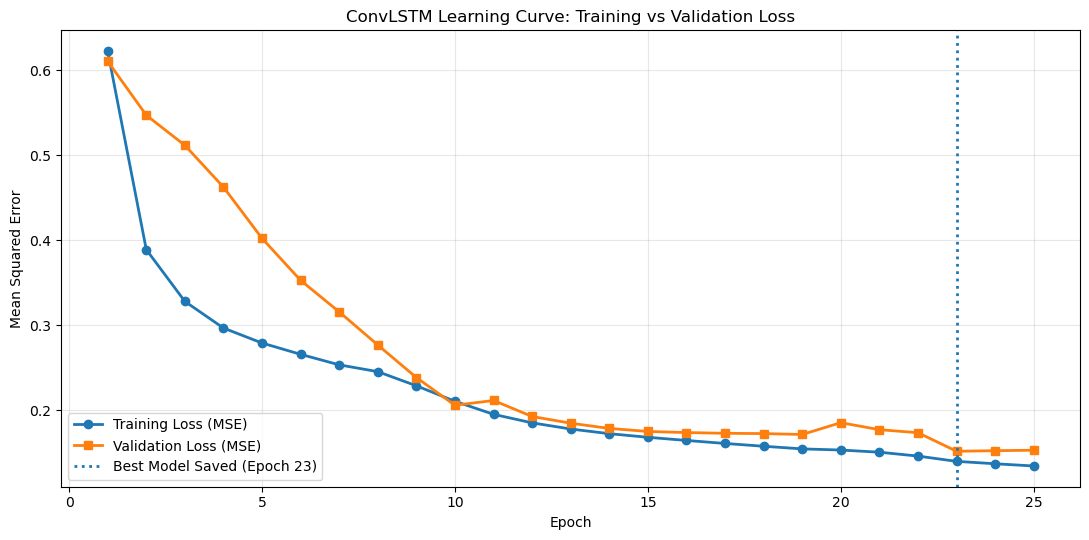

Best epoch: 23
Best validation MSE: 0.151613


In [10]:
# Learning curve
history_data = history.history

train_loss = np.asarray(history_data["loss"])
val_loss = np.asarray(history_data["val_loss"])
epochs_ran = np.arange(1, len(train_loss) + 1)
best_epoch = int(np.argmin(val_loss) + 1)

plt.figure(figsize=(11, 5.5))
plt.plot(
    epochs_ran,
    train_loss,
    marker="o",
    linewidth=2,
    label="Training Loss (MSE)",
)
plt.plot(
    epochs_ran,
    val_loss,
    marker="s",
    linewidth=2,
    label="Validation Loss (MSE)",
)
plt.axvline(
    best_epoch,
    linestyle=":",
    linewidth=2,
    label=f"Best Model Saved (Epoch {best_epoch})",
)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("ConvLSTM Learning Curve: Training vs Validation Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best epoch: {best_epoch}")
print(f"Best validation MSE: {val_loss[best_epoch - 1]:.6f}")

In [11]:
# One step ahead test predictions

def inverse_scale(values):
    return values * feature_std + feature_mean


y_test_pred_scaled = model.predict(
    X_test,
    batch_size=BATCH_SIZE,
    verbose=1,
)

y_test_true = inverse_scale(y_test)
y_test_pred = inverse_scale(y_test_pred_scaled)

print("One-step test truth:", y_test_true.shape)
print("One-step test predictions:", y_test_pred.shape)

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step
One-step test truth: (60, 41, 41, 8)
One-step test predictions: (60, 41, 41, 8)


In [12]:
# Recursive 5 year forecast (Jan1982 to Dec 1986)

forecast_months = pd.date_range(FORECAST_START, FORECAST_END, freq="MS")

history_end_index = np.where(times < FORECAST_START)[0][-1]
initial_start = history_end_index - LOOKBACK + 1

initial_times = times[initial_start:history_end_index + 1]
if not months_are_consecutive(initial_times):
    raise ValueError(
        "The 12 months immediately preceding the forecast are not consecutive"
    )

rolling_window = data_scaled[
    initial_start:history_end_index + 1
].copy()

recursive_scaled = []

for timestamp in forecast_months:
    prediction = model.predict(
        rolling_window[np.newaxis, ...],
        verbose=0,
    )[0]

    recursive_scaled.append(prediction)
    rolling_window = np.concatenate(
        [rolling_window[1:], prediction[np.newaxis, ...]],
        axis=0,
    )

recursive_scaled = np.asarray(recursive_scaled, dtype=np.float32)
recursive_forecast = inverse_scale(recursive_scaled)

forecast_truth_raw = raw_data[
    (times >= FORECAST_START) & (times <= FORECAST_END)
]
forecast_truth_times = times[
    (times >= FORECAST_START) & (times <= FORECAST_END)
]

if not forecast_truth_times.equals(forecast_months):
    raise ValueError(
        "Observed truth is missing one or more forecast months. "
        "Use the one-step test evaluation for the available months."
    )

print("Recursive forecast:", recursive_forecast.shape)
print("Forecast period:", forecast_months[0], "to", forecast_months[-1])

Recursive forecast: (60, 41, 41, 8)
Forecast period: 1982-01-01 00:00:00 to 1986-12-01 00:00:00


In [13]:
# Metric helpers

def safe_metrics(actual, predicted):
    actual = np.asarray(actual).ravel()
    predicted = np.asarray(predicted).ravel()

    valid = np.isfinite(actual) & np.isfinite(predicted)
    actual = actual[valid]
    predicted = predicted[valid]

    if len(actual) == 0:
        return {
            "MAE": np.nan,
            "RMSE": np.nan,
            "R2": np.nan,
            "Bias": np.nan,
            "Pearson_r": np.nan,
            "n_valid": 0,
        }

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted) if len(actual) > 1 else np.nan
    bias = np.mean(predicted - actual)

    if len(actual) > 1 and np.std(actual) > 0 and np.std(predicted) > 0:
        correlation = pearsonr(actual, predicted).statistic
    else:
        correlation = np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Bias": bias,
        "Pearson_r": correlation,
        "n_valid": int(len(actual)),
    }


def feature_metrics_table(actual, predicted, feature_names):
    rows = []
    for feature_index, feature_name in enumerate(feature_names):
        row = {"feature": feature_name}
        row.update(
            safe_metrics(
                actual[..., feature_index],
                predicted[..., feature_index],
            )
        )
        rows.append(row)
    return pd.DataFrame(rows)


one_step_metrics_df = feature_metrics_table(
    y_test_true,
    y_test_pred,
    features,
)

recursive_metrics_df = feature_metrics_table(
    forecast_truth_raw,
    recursive_forecast,
    features,
)

print("ONE-STEP-AHEAD TEST METRICS")
display(one_step_metrics_df)

print("RECURSIVE FIVE-YEAR FORECAST METRICS")
display(recursive_metrics_df)

ONE-STEP-AHEAD TEST METRICS


,feature,MAE,RMSE,R2,Bias,Pearson_r,n_valid
0,sst,0.537005,0.773382,0.963047,-0.043679,0.981414,100860
1,salinity,0.114648,0.156760,0.943742,-0.051216,0.976585,100860
2,thetao,0.457522,0.675412,0.965183,-0.027550,0.983249,100860
3,qnet,49.914310,81.472283,0.771321,-8.572670,0.880744,100860
4,u_current,0.029067,0.054701,0.567504,0.001850,0.754564,100860
5,v_current,0.028149,0.052877,0.549476,0.002531,0.742308,100860
6,era5_sst,0.587482,0.843812,0.958061,-0.056191,0.978952,100860
7,era5_runoff,0.039538,0.066363,0.000000,-0.001835,NaN,100860


RECURSIVE FIVE-YEAR FORECAST METRICS


,feature,MAE,RMSE,R2,Bias,Pearson_r,n_valid
0,sst,1.512097,1.996994,0.753617,-1.034654,0.905529,100860
1,salinity,0.406524,0.525520,0.367740,-0.295761,0.772736,100860
2,thetao,1.489695,1.884228,0.729028,-1.089845,0.913127,100860
3,qnet,78.424072,121.669940,0.489998,-19.684710,0.715575,100860
4,u_current,0.053788,0.088073,-0.121196,0.009972,0.240872,100860
5,v_current,0.041721,0.074483,0.106091,0.001287,0.399064,100860
6,era5_sst,1.546865,2.045473,0.753561,-1.024722,0.904016,100860
7,era5_runoff,0.035845,0.067214,0.000000,0.001719,NaN,100860


In [14]:
# Persistence baseline and forecast skill

# Persistence predicts that the next month equals the previous observed month
persistence_predictions = []

for timestamp in forecast_months:
    current_index = times.get_loc(timestamp)
    persistence_predictions.append(raw_data[current_index - 1])

persistence_predictions = np.asarray(persistence_predictions)

baseline_rows = []

for feature_index, feature_name in enumerate(features):
    actual = forecast_truth_raw[..., feature_index]
    conv = recursive_forecast[..., feature_index]
    persistence = persistence_predictions[..., feature_index]

    conv_metrics = safe_metrics(actual, conv)
    persistence_metrics = safe_metrics(actual, persistence)

    rmse_skill = (
        1 - conv_metrics["RMSE"] / persistence_metrics["RMSE"]
        if persistence_metrics["RMSE"] > 0
        else np.nan
    )

    baseline_rows.append({
        "feature": feature_name,
        "ConvLSTM_MAE": conv_metrics["MAE"],
        "Persistence_MAE": persistence_metrics["MAE"],
        "ConvLSTM_RMSE": conv_metrics["RMSE"],
        "Persistence_RMSE": persistence_metrics["RMSE"],
        "RMSE_skill_vs_persistence": rmse_skill,
        "ConvLSTM_R2": conv_metrics["R2"],
        "Persistence_R2": persistence_metrics["R2"],
    })

baseline_comparison_df = pd.DataFrame(baseline_rows)
display(baseline_comparison_df)

,feature,ConvLSTM_MAE,Persistence_MAE,ConvLSTM_RMSE,Persistence_RMSE,RMSE_skill_vs_persistence,ConvLSTM_R2,Persistence_R2
0,sst,1.512097,1.230123,1.996994,1.496828,-0.334151,0.753617,0.861579
1,salinity,0.406524,0.057997,0.525520,0.099697,-4.271157,0.367740,0.977245
2,thetao,1.489695,0.901815,1.884228,1.075063,-0.752667,0.729028,0.911789
3,qnet,78.424072,71.572296,121.669940,105.049728,-0.158213,0.489998,0.619815
4,u_current,0.053788,0.031438,0.088073,0.062130,-0.417543,-0.121196,0.442032
5,v_current,0.041721,0.033481,0.074483,0.062615,-0.189547,0.106091,0.368272
6,era5_sst,1.546865,1.226716,2.045473,1.509305,-0.355242,0.753561,0.865824
7,era5_runoff,0.035845,0.000000,0.067214,0.000000,NaN,0.000000,1.000000


In [15]:
# Shreya metrics

PRIMARY_FEATURE = "sst"
primary_index = features.index(PRIMARY_FEATURE)

period_rows = []

for n_years in range(1, 6):
    n_months = n_years * 12

    metrics = safe_metrics(
        forecast_truth_raw[:n_months, ..., primary_index],
        recursive_forecast[:n_months, ..., primary_index],
    )

    period_rows.append({
        "evaluation_period": f"{n_years} year" if n_years == 1 else f"{n_years} years",
        "start": forecast_months[0].strftime("%Y-%m"),
        "end": forecast_months[n_months - 1].strftime("%Y-%m"),
        **metrics,
    })

forecast_period_metrics_df = pd.DataFrame(period_rows)
display(forecast_period_metrics_df)

,evaluation_period,start,end,MAE,RMSE,R2,Bias,Pearson_r,n_valid
0,1 year,1982-01,1982-12,0.878525,1.137359,0.925175,-0.328414,0.973133,20172
1,2 years,1982-01,1983-12,1.088826,1.431264,0.869531,-0.663995,0.949799,40344
2,3 years,1982-01,1984-12,1.248175,1.632635,0.826362,-0.840329,0.934961,60516
3,4 years,1982-01,1985-12,1.353330,1.773838,0.802270,-0.896092,0.924264,80688
4,5 years,1982-01,1986-12,1.512097,1.996994,0.753617,-1.034654,0.905529,100860


In [16]:
# Metrics by forecast year

year_rows = []

for year in range(FORECAST_START.year, FORECAST_END.year + 1):
    year_mask = forecast_months.year == year

    for feature_index, feature_name in enumerate(features):
        row = {
            "year": year,
            "feature": feature_name,
        }
        row.update(
            safe_metrics(
                forecast_truth_raw[year_mask, ..., feature_index],
                recursive_forecast[year_mask, ..., feature_index],
            )
        )
        year_rows.append(row)

yearly_metrics_df = pd.DataFrame(year_rows)

display(
    yearly_metrics_df[
        yearly_metrics_df["feature"] == PRIMARY_FEATURE
    ].reset_index(drop=True)
)

,year,feature,MAE,RMSE,R2,Bias,Pearson_r,n_valid
0,1982,sst,0.878525,1.137359,0.925175,-0.328414,0.973133,20172
1,1983,sst,1.299128,1.674351,0.801089,-0.999576,0.933912,20172
2,1984,sst,1.566872,1.974704,0.733815,-1.192997,0.911593,20172
3,1985,sst,1.668797,2.142315,0.738097,-1.063381,0.896658,20172
4,1986,sst,2.147161,2.711811,0.573552,-1.588902,0.850231,20172


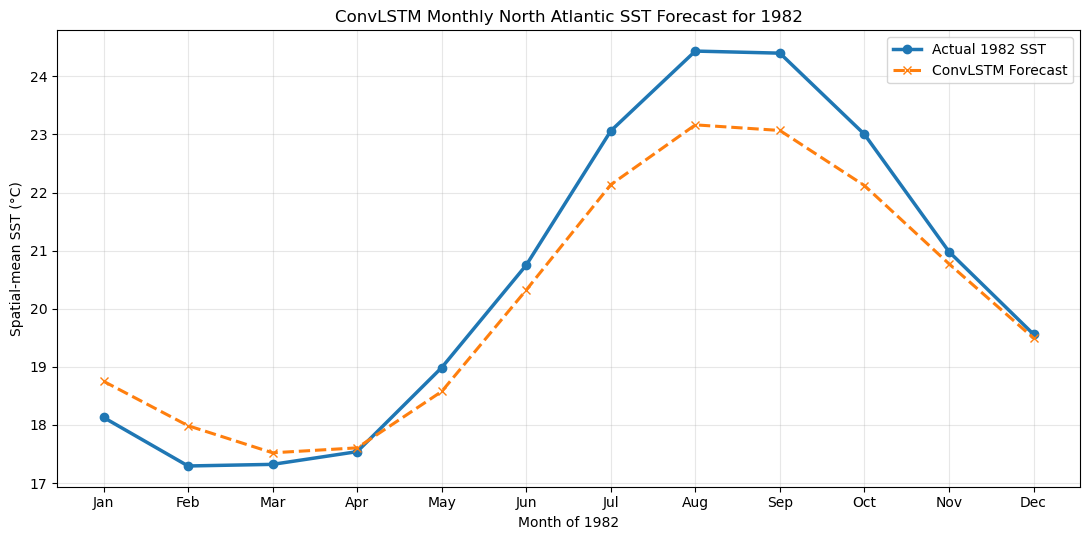

In [17]:
# Shreya style monty forecast for one year

PLOT_YEAR = 1982
year_mask = forecast_months.year == PLOT_YEAR

actual_monthly_mean = np.nanmean(
    forecast_truth_raw[year_mask, ..., primary_index],
    axis=(1, 2),
)
predicted_monthly_mean = np.nanmean(
    recursive_forecast[year_mask, ..., primary_index],
    axis=(1, 2),
)

months = forecast_months[year_mask].strftime("%b")

plt.figure(figsize=(11, 5.5))
plt.plot(
    months,
    actual_monthly_mean,
    marker="o",
    linewidth=2.5,
    label=f"Actual {PLOT_YEAR} {PRIMARY_FEATURE.upper()}",
)
plt.plot(
    months,
    predicted_monthly_mean,
    marker="x",
    linestyle="--",
    linewidth=2.2,
    label="ConvLSTM Forecast",
)
plt.xlabel(f"Month of {PLOT_YEAR}")
plt.ylabel("Spatial-mean SST (°C)")
plt.title(
    f"ConvLSTM Monthly North Atlantic SST Forecast for {PLOT_YEAR}"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

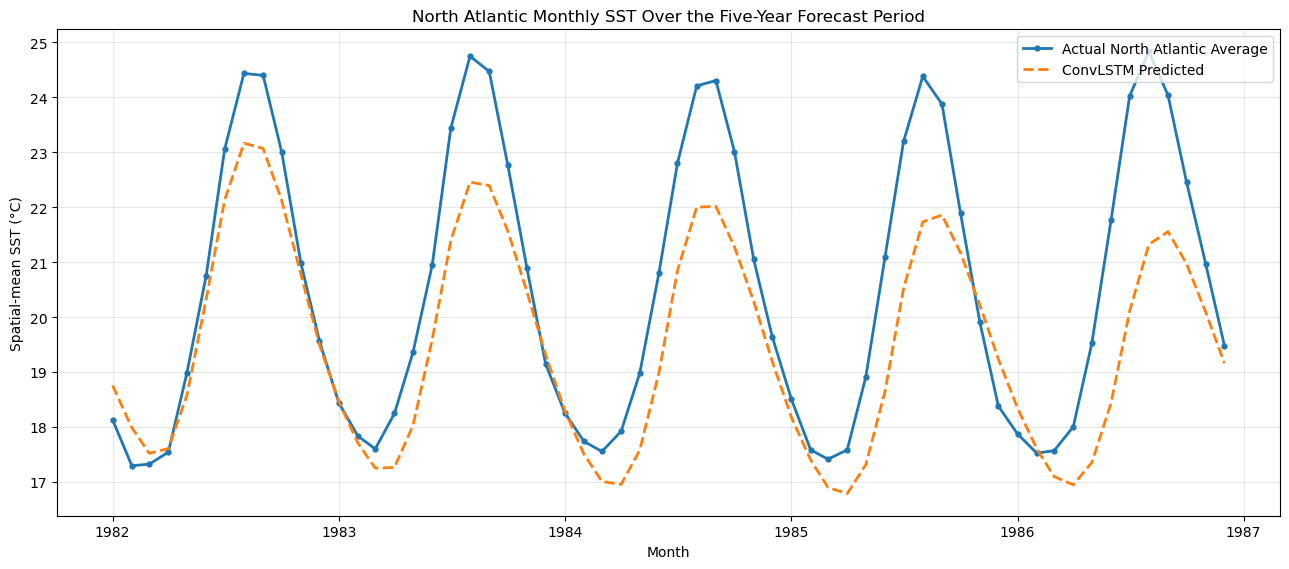

In [18]:
# Temporal trend over full period

actual_spatial_mean = np.nanmean(
    forecast_truth_raw[..., primary_index],
    axis=(1, 2),
)
predicted_spatial_mean = np.nanmean(
    recursive_forecast[..., primary_index],
    axis=(1, 2),
)

plt.figure(figsize=(13, 5.8))
plt.plot(
    forecast_months,
    actual_spatial_mean,
    marker="o",
    markersize=3.5,
    linewidth=2,
    label="Actual North Atlantic Average",
)
plt.plot(
    forecast_months,
    predicted_spatial_mean,
    linestyle="--",
    linewidth=2,
    label="ConvLSTM Predicted",
)
plt.xlabel("Month")
plt.ylabel("Spatial-mean SST (°C)")
plt.title("North Atlantic Monthly SST Over the Five-Year Forecast Period")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

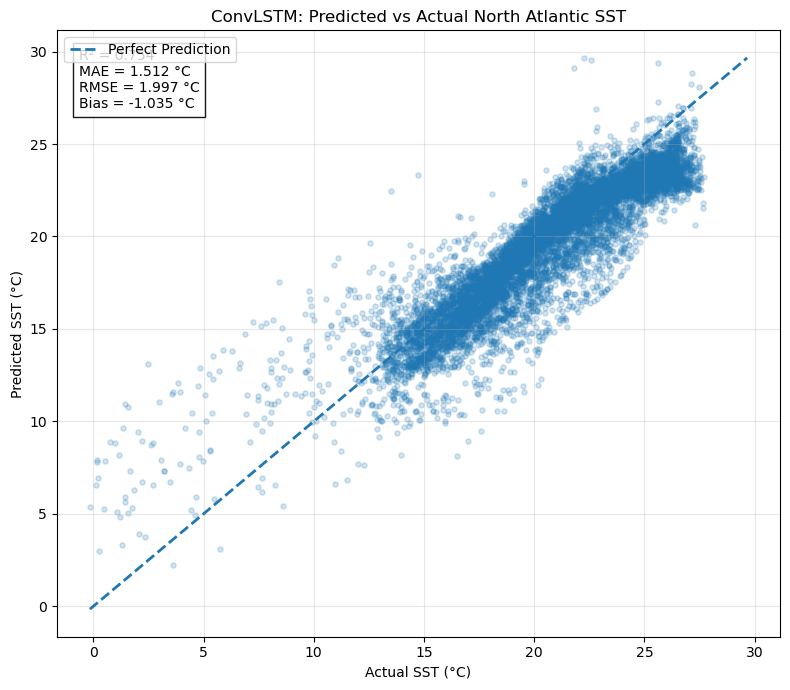

In [19]:
# Shreya scatter actual vs predicted

rng = np.random.default_rng(42)

actual_flat = forecast_truth_raw[..., primary_index].ravel()
predicted_flat = recursive_forecast[..., primary_index].ravel()

valid = np.isfinite(actual_flat) & np.isfinite(predicted_flat)
actual_valid = actual_flat[valid]
predicted_valid = predicted_flat[valid]

sample_size = min(10_000, len(actual_valid))
sample_indices = rng.choice(
    len(actual_valid),
    size=sample_size,
    replace=False,
)

sample_actual = actual_valid[sample_indices]
sample_predicted = predicted_valid[sample_indices]

limits = [
    min(sample_actual.min(), sample_predicted.min()),
    max(sample_actual.max(), sample_predicted.max()),
]

scatter_metrics = safe_metrics(actual_valid, predicted_valid)

plt.figure(figsize=(8, 7))
plt.scatter(
    sample_actual,
    sample_predicted,
    alpha=0.20,
    s=14,
)
plt.plot(
    limits,
    limits,
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction",
)
plt.xlabel("Actual SST (°C)")
plt.ylabel("Predicted SST (°C)")
plt.title("ConvLSTM: Predicted vs Actual North Atlantic SST")
plt.grid(alpha=0.3)
plt.legend()
plt.text(
    0.03,
    0.97,
    (
        f"R² = {scatter_metrics['R2']:.3f}\n"
        f"MAE = {scatter_metrics['MAE']:.3f} °C\n"
        f"RMSE = {scatter_metrics['RMSE']:.3f} °C\n"
        f"Bias = {scatter_metrics['Bias']:.3f} °C"
    ),
    transform=plt.gca().transAxes,
    va="top",
    bbox={"facecolor": "white", "alpha": 0.9},
)
plt.tight_layout()
plt.show()

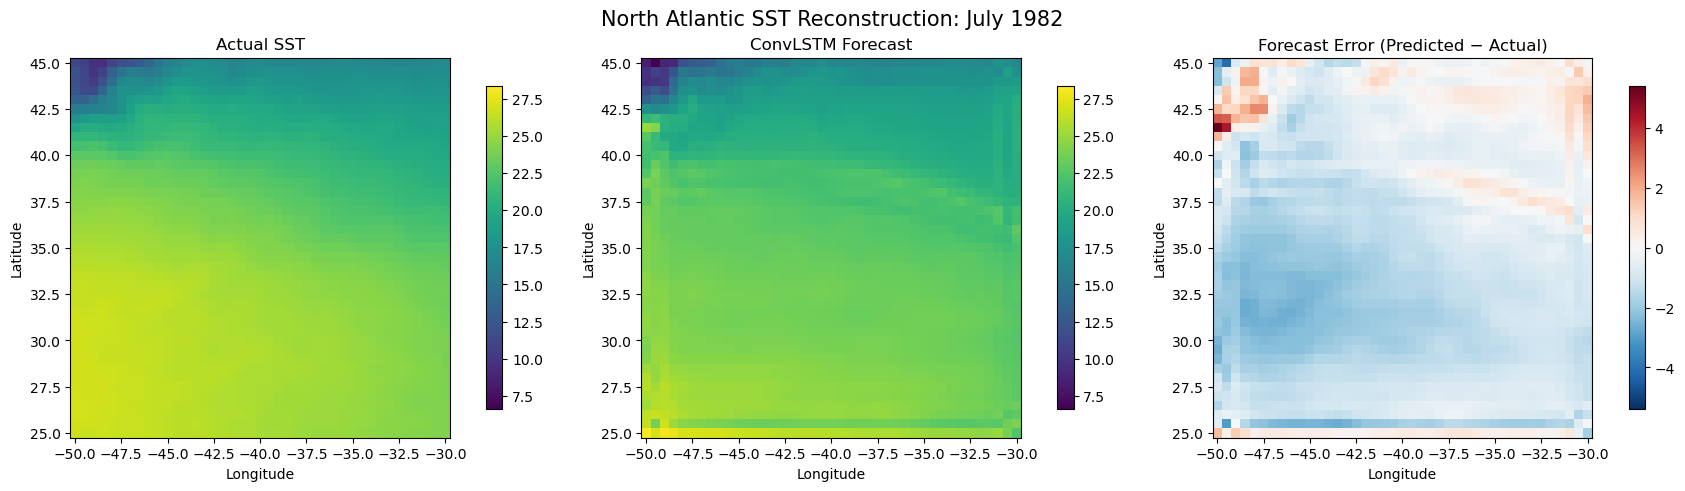

In [20]:
# Maps

SAMPLE_MONTH = pd.Timestamp("1982-07-01")
sample_index = forecast_months.get_loc(SAMPLE_MONTH)

actual_map = forecast_truth_raw[sample_index, ..., primary_index]
predicted_map = recursive_forecast[sample_index, ..., primary_index]
error_map = predicted_map - actual_map

lats = combined_monthly.lat.values
lons = combined_monthly.lon.values

common_vmin = np.nanmin([actual_map, predicted_map])
common_vmax = np.nanmax([actual_map, predicted_map])
error_limit = np.nanmax(np.abs(error_map))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), constrained_layout=True)

plots = [
    (actual_map, "Actual SST", common_vmin, common_vmax, "viridis"),
    (predicted_map, "ConvLSTM Forecast", common_vmin, common_vmax, "viridis"),
    (error_map, "Forecast Error (Predicted − Actual)", -error_limit, error_limit, "RdBu_r"),
]

for ax, (field, title, vmin, vmax, cmap) in zip(axes, plots):
    mesh = ax.pcolormesh(
        lons,
        lats,
        field,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title)
    ax.set_aspect("equal")
    fig.colorbar(mesh, ax=ax, shrink=0.85)

fig.suptitle(
    f"North Atlantic SST Reconstruction: {SAMPLE_MONTH:%B %Y}",
    fontsize=15,
)
plt.show()

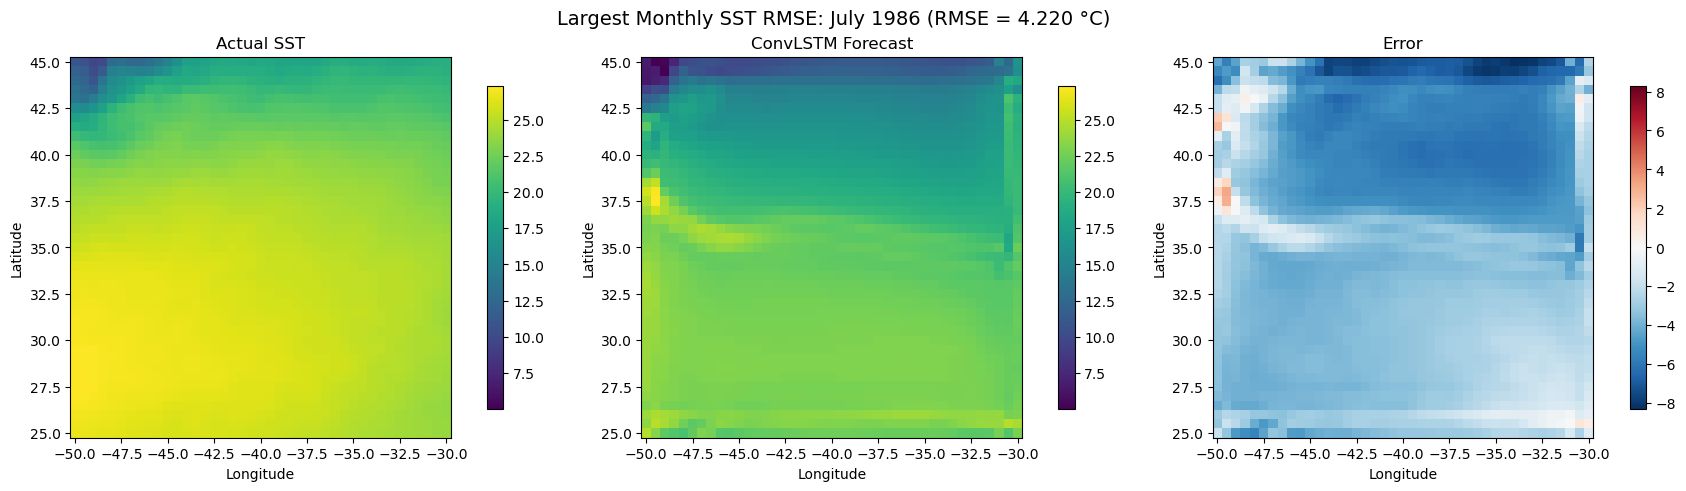

In [21]:
# Largest error

monthly_rmse = []

for month_index in range(len(forecast_months)):
    metrics = safe_metrics(
        forecast_truth_raw[month_index, ..., primary_index],
        recursive_forecast[month_index, ..., primary_index],
    )
    monthly_rmse.append(metrics["RMSE"])

monthly_rmse = np.asarray(monthly_rmse)
worst_index = int(np.nanargmax(monthly_rmse))
worst_month = forecast_months[worst_index]

actual_extreme = forecast_truth_raw[worst_index, ..., primary_index]
predicted_extreme = recursive_forecast[worst_index, ..., primary_index]
error_extreme = predicted_extreme - actual_extreme

common_vmin = np.nanmin([actual_extreme, predicted_extreme])
common_vmax = np.nanmax([actual_extreme, predicted_extreme])
error_limit = np.nanmax(np.abs(error_extreme))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), constrained_layout=True)

plots = [
    (actual_extreme, "Actual SST", common_vmin, common_vmax, "viridis"),
    (predicted_extreme, "ConvLSTM Forecast", common_vmin, common_vmax, "viridis"),
    (error_extreme, "Error", -error_limit, error_limit, "RdBu_r"),
]

for ax, (field, title, vmin, vmax, cmap) in zip(axes, plots):
    mesh = ax.pcolormesh(
        lons,
        lats,
        field,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title)
    ax.set_aspect("equal")
    fig.colorbar(mesh, ax=ax, shrink=0.85)

fig.suptitle(
    f"Largest Monthly SST RMSE: {worst_month:%B %Y} "
    f"(RMSE = {monthly_rmse[worst_index]:.3f} °C)",
    fontsize=14,
)
plt.show()

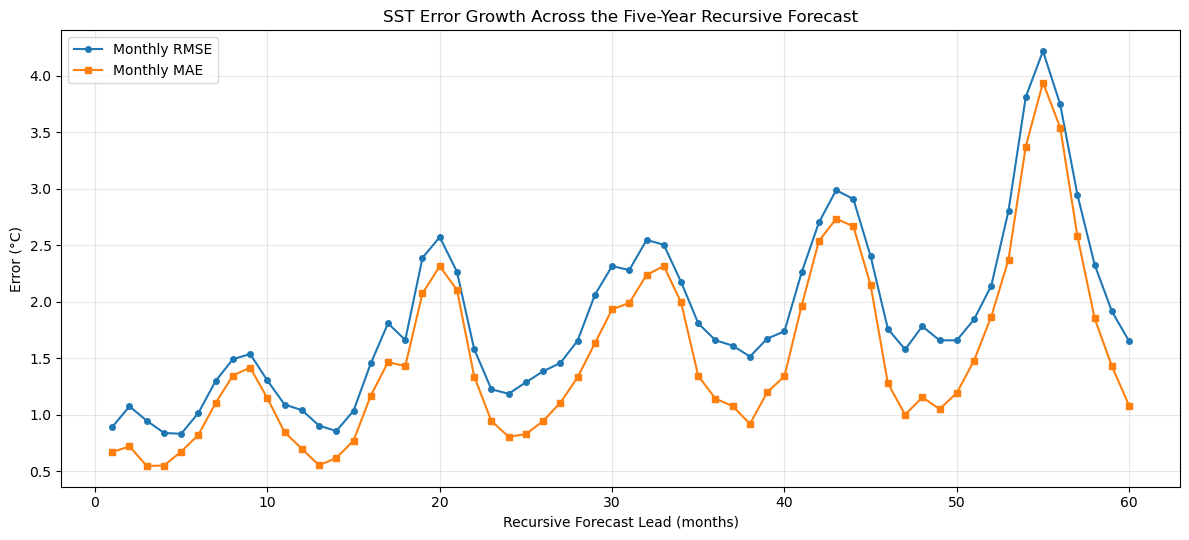

,lead_month,date,MAE,RMSE,R2,Bias,Pearson_r,n_valid
0,1,1982-01-01,0.669960,0.891755,0.925354,0.622578,0.981839,1681
1,2,1982-02-01,0.719924,1.074058,0.895248,0.693115,0.969812,1681
2,3,1982-03-01,0.546380,0.947629,0.925163,0.198933,0.964210,1681
3,4,1982-04-01,0.550289,0.839005,0.938635,0.065367,0.969418,1681
4,5,1982-05-01,0.673523,0.830968,0.930711,-0.410891,0.977943,1681
5,6,1982-06-01,0.822846,1.016253,0.929678,-0.428239,0.982174,1681
6,7,1982-07-01,1.104750,1.299569,0.829657,-0.925276,0.965993,1681
7,8,1982-08-01,1.346996,1.491678,0.622603,-1.269829,0.947054,1681
8,9,1982-09-01,1.417612,1.537701,0.581252,-1.330546,0.945992,1681
9,10,1982-10-01,1.146342,1.303452,0.830342,-0.882054,0.969376,1681


In [22]:
# Error growth with forecast lead time

lead_rows = []

for lead, timestamp in enumerate(forecast_months, start=1):
    metrics = safe_metrics(
        forecast_truth_raw[lead - 1, ..., primary_index],
        recursive_forecast[lead - 1, ..., primary_index],
    )
    lead_rows.append({
        "lead_month": lead,
        "date": timestamp,
        **metrics,
    })

lead_metrics_df = pd.DataFrame(lead_rows)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(
    lead_metrics_df["lead_month"],
    lead_metrics_df["RMSE"],
    marker="o",
    markersize=4,
    label="Monthly RMSE",
)
ax.plot(
    lead_metrics_df["lead_month"],
    lead_metrics_df["MAE"],
    marker="s",
    markersize=4,
    label="Monthly MAE",
)
ax.set_xlabel("Recursive Forecast Lead (months)")
ax.set_ylabel("Error (°C)")
ax.set_title("SST Error Growth Across the Five-Year Recursive Forecast")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

display(lead_metrics_df)

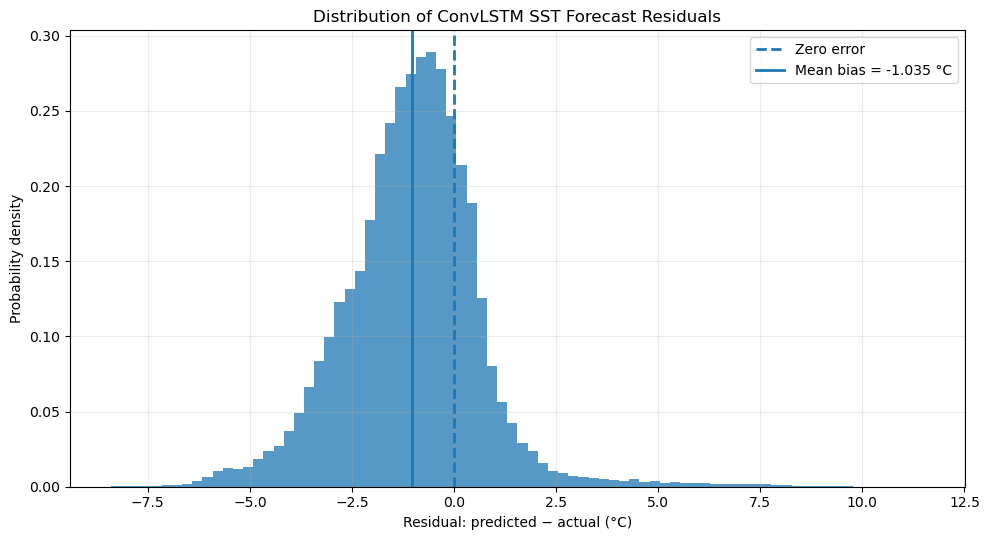

Residual standard deviation: 1.7080624
Residual median: -0.97061443
95th percentile absolute error: 4.018658256530761


In [23]:
# =============================================================================
# RESIDUAL DISTRIBUTION AND BIAS
# =============================================================================

residuals = predicted_valid - actual_valid

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(
    residuals,
    bins=80,
    density=True,
    alpha=0.75,
)
ax.axvline(0, linestyle="--", linewidth=2, label="Zero error")
ax.axvline(
    np.mean(residuals),
    linestyle="-",
    linewidth=2,
    label=f"Mean bias = {np.mean(residuals):.3f} °C",
)
ax.set_xlabel("Residual: predicted − actual (°C)")
ax.set_ylabel("Probability density")
ax.set_title("Distribution of ConvLSTM SST Forecast Residuals")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

print("Residual standard deviation:", np.std(residuals))
print("Residual median:", np.median(residuals))
print("95th percentile absolute error:", np.percentile(np.abs(residuals), 95))

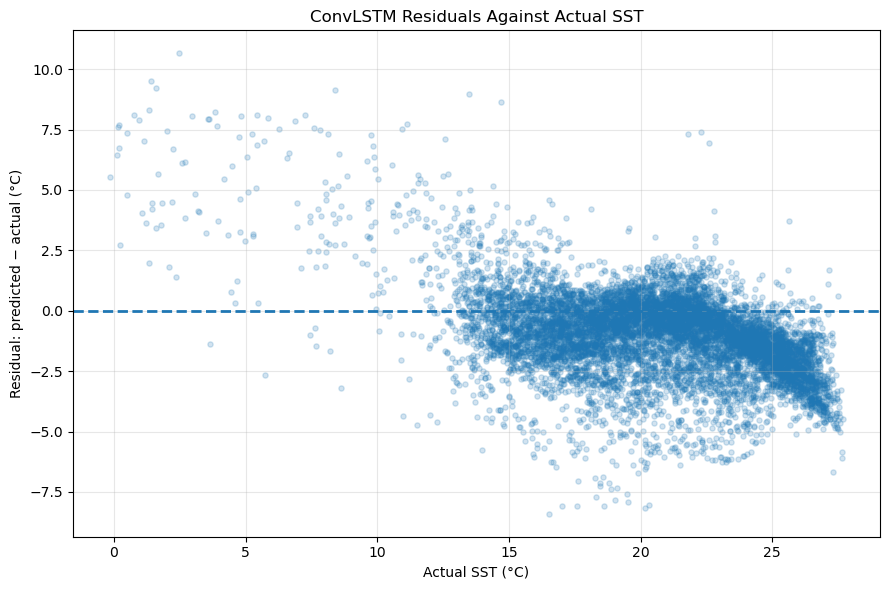

In [24]:
# REsiduals vs actual

sample_residuals = sample_predicted - sample_actual

plt.figure(figsize=(9, 6))
plt.scatter(
    sample_actual,
    sample_residuals,
    alpha=0.20,
    s=14,
)
plt.axhline(0, linestyle="--", linewidth=2)
plt.xlabel("Actual SST (°C)")
plt.ylabel("Residual: predicted − actual (°C)")
plt.title("ConvLSTM Residuals Against Actual SST")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

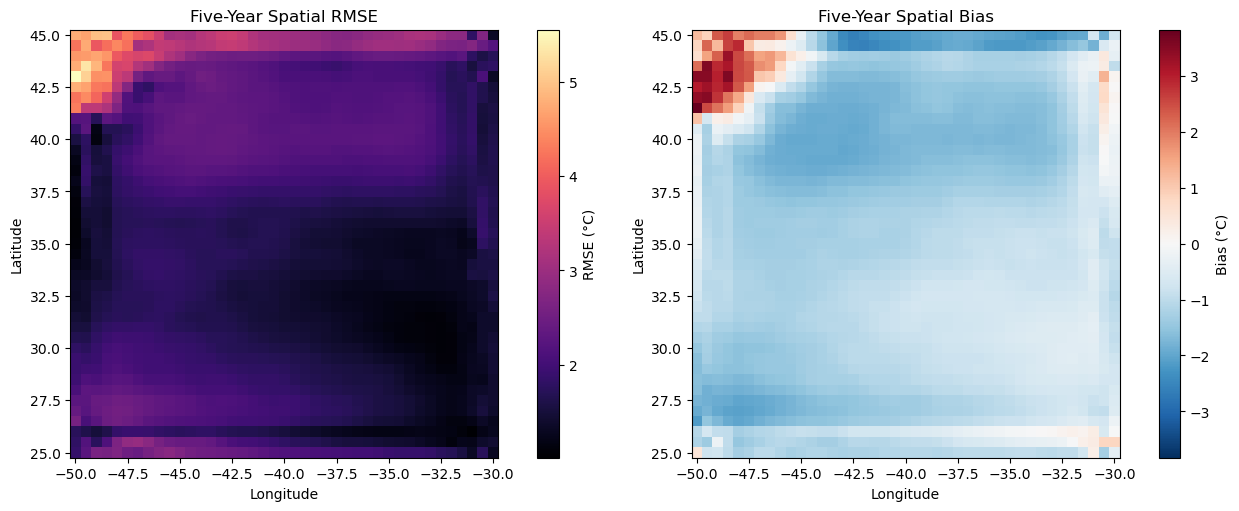

In [25]:
# Spatial rmse and bias maps

actual_primary = forecast_truth_raw[..., primary_index]
predicted_primary = recursive_forecast[..., primary_index]

spatial_error = predicted_primary - actual_primary
spatial_rmse = np.sqrt(np.nanmean(spatial_error ** 2, axis=0))
spatial_bias = np.nanmean(spatial_error, axis=0)

bias_limit = np.nanmax(np.abs(spatial_bias))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5), constrained_layout=True)

rmse_mesh = axes[0].pcolormesh(
    lons,
    lats,
    spatial_rmse,
    shading="auto",
    cmap="magma",
)
axes[0].set_title("Five-Year Spatial RMSE")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_aspect("equal")
fig.colorbar(rmse_mesh, ax=axes[0], label="RMSE (°C)")

bias_mesh = axes[1].pcolormesh(
    lons,
    lats,
    spatial_bias,
    shading="auto",
    cmap="RdBu_r",
    vmin=-bias_limit,
    vmax=bias_limit,
)
axes[1].set_title("Five-Year Spatial Bias")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_aspect("equal")
fig.colorbar(bias_mesh, ax=axes[1], label="Bias (°C)")

plt.show()

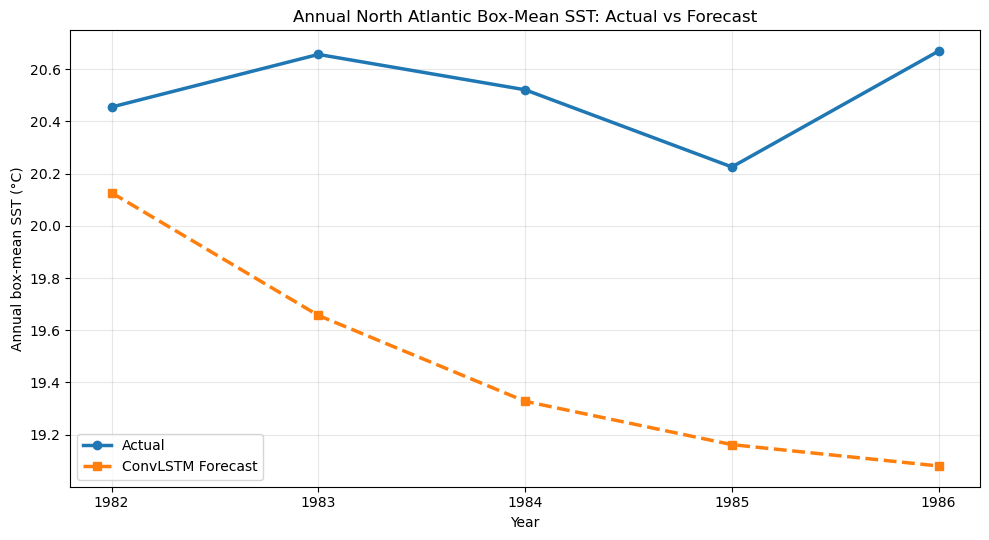

,year,actual,predicted
0,1982,20.454927,20.126513
1,1983,20.656385,19.656809
2,1984,20.520947,19.327951
3,1985,20.225365,19.161983
4,1986,20.669170,19.080269


In [26]:
# Actual vs forecast spatial mean sst

annual_rows = []

for year in range(FORECAST_START.year, FORECAST_END.year + 1):
    mask = forecast_months.year == year

    annual_rows.append({
        "year": year,
        "actual": np.nanmean(
            forecast_truth_raw[mask, ..., primary_index]
        ),
        "predicted": np.nanmean(
            recursive_forecast[mask, ..., primary_index]
        ),
    })

annual_mean_df = pd.DataFrame(annual_rows)

plt.figure(figsize=(10, 5.5))
plt.plot(
    annual_mean_df["year"],
    annual_mean_df["actual"],
    marker="o",
    linewidth=2.5,
    label="Actual",
)
plt.plot(
    annual_mean_df["year"],
    annual_mean_df["predicted"],
    marker="s",
    linestyle="--",
    linewidth=2.5,
    label="ConvLSTM Forecast",
)
plt.xlabel("Year")
plt.ylabel("Annual box-mean SST (°C)")
plt.title("Annual North Atlantic Box-Mean SST: Actual vs Forecast")
plt.xticks(annual_mean_df["year"])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

display(annual_mean_df)

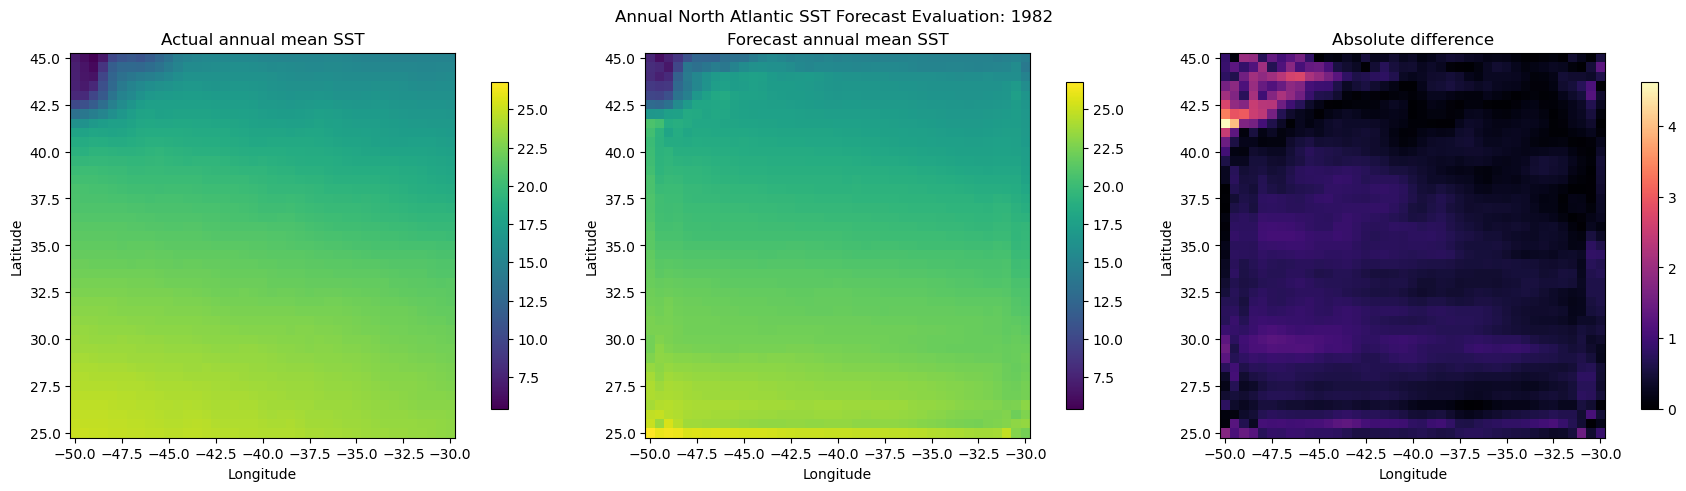

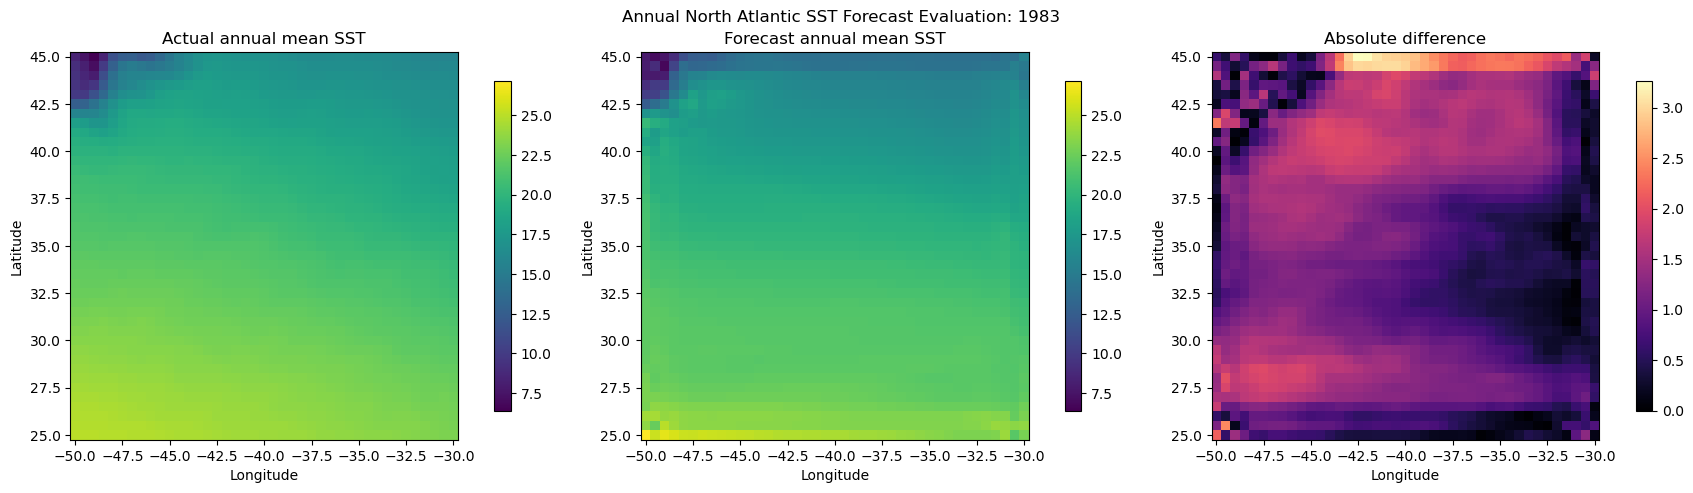

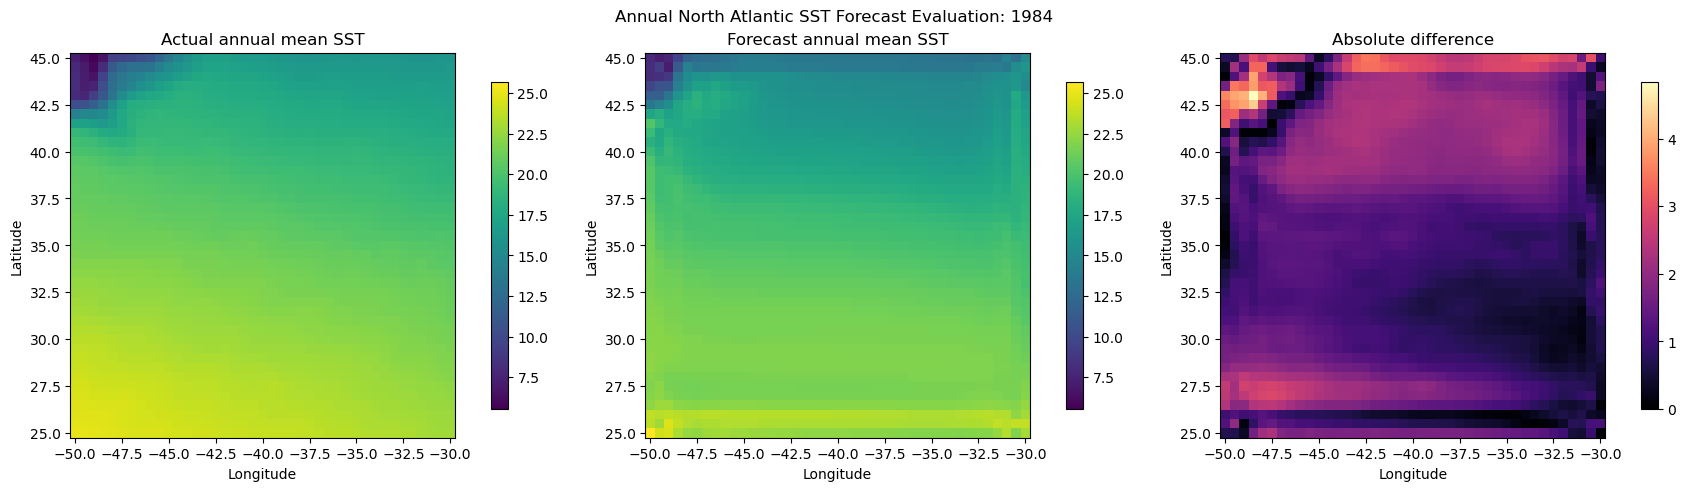

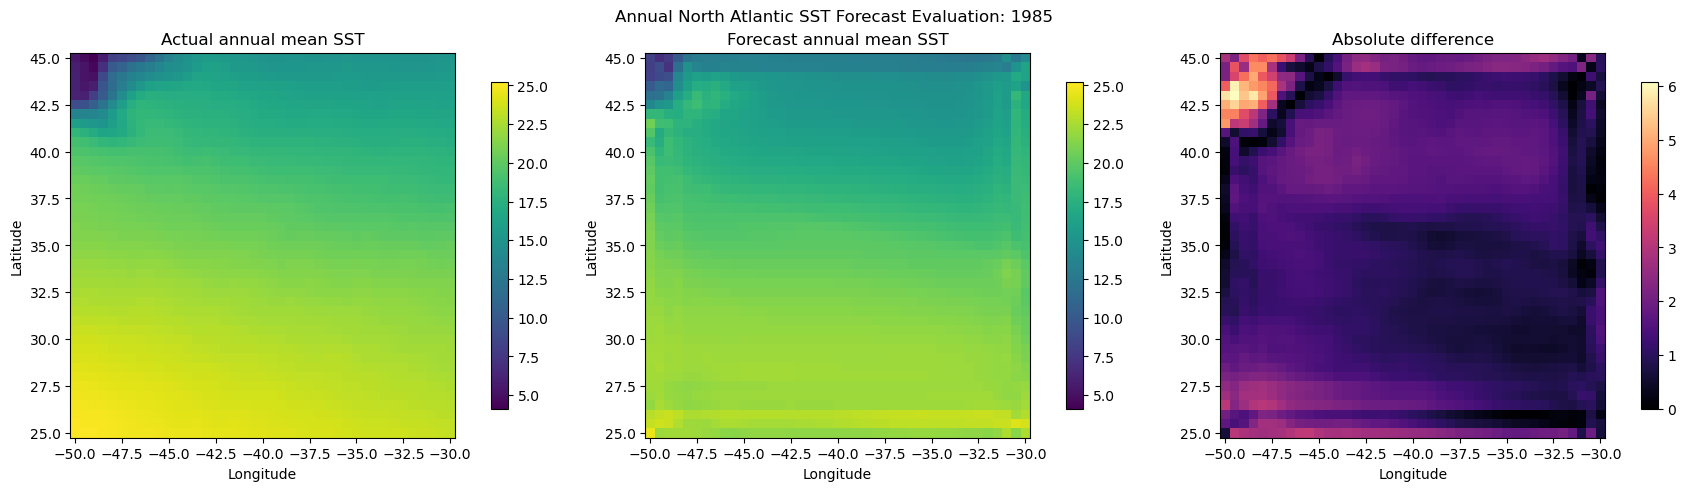

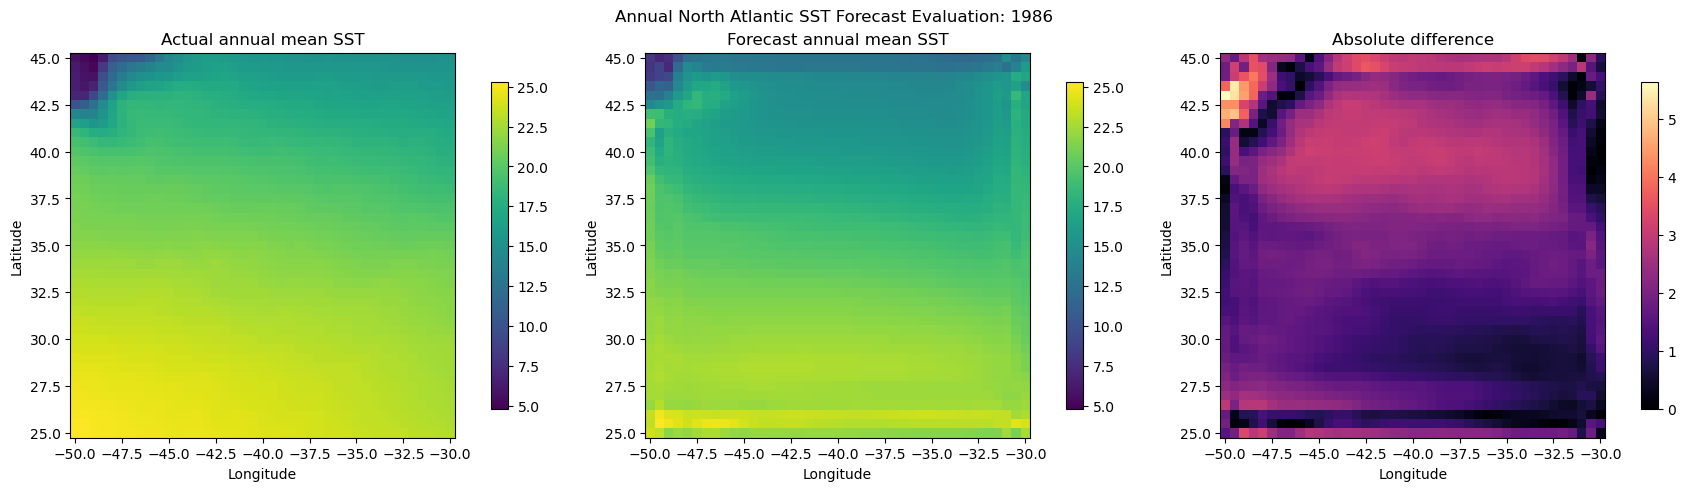

In [28]:
# Maps

for year in range(FORECAST_START.year, FORECAST_END.year + 1):
    mask = forecast_months.year == year

    actual_map = np.nanmean(
        forecast_truth_raw[mask, ..., primary_index],
        axis=0,
    )
    predicted_map = np.nanmean(
        recursive_forecast[mask, ..., primary_index],
        axis=0,
    )
    absolute_difference = np.abs(predicted_map - actual_map)

    common_vmin = np.nanmin([actual_map, predicted_map])
    common_vmax = np.nanmax([actual_map, predicted_map])

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(17, 4.8),
        constrained_layout=True,
    )

    fields = [
        (actual_map, "Actual annual mean SST", common_vmin, common_vmax, "viridis"),
        (predicted_map, "Forecast annual mean SST", common_vmin, common_vmax, "viridis"),
        (absolute_difference, "Absolute difference", 0, np.nanmax(absolute_difference), "magma"),
    ]

    for ax, (field, title, vmin, vmax, cmap) in zip(axes, fields):
        mesh = ax.pcolormesh(
            lons,
            lats,
            field,
            shading="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(title)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_aspect("equal")
        fig.colorbar(mesh, ax=ax, shrink=0.85)

    fig.suptitle(f"Annual North Atlantic SST Forecast Evaluation: {year}")
    plt.show()

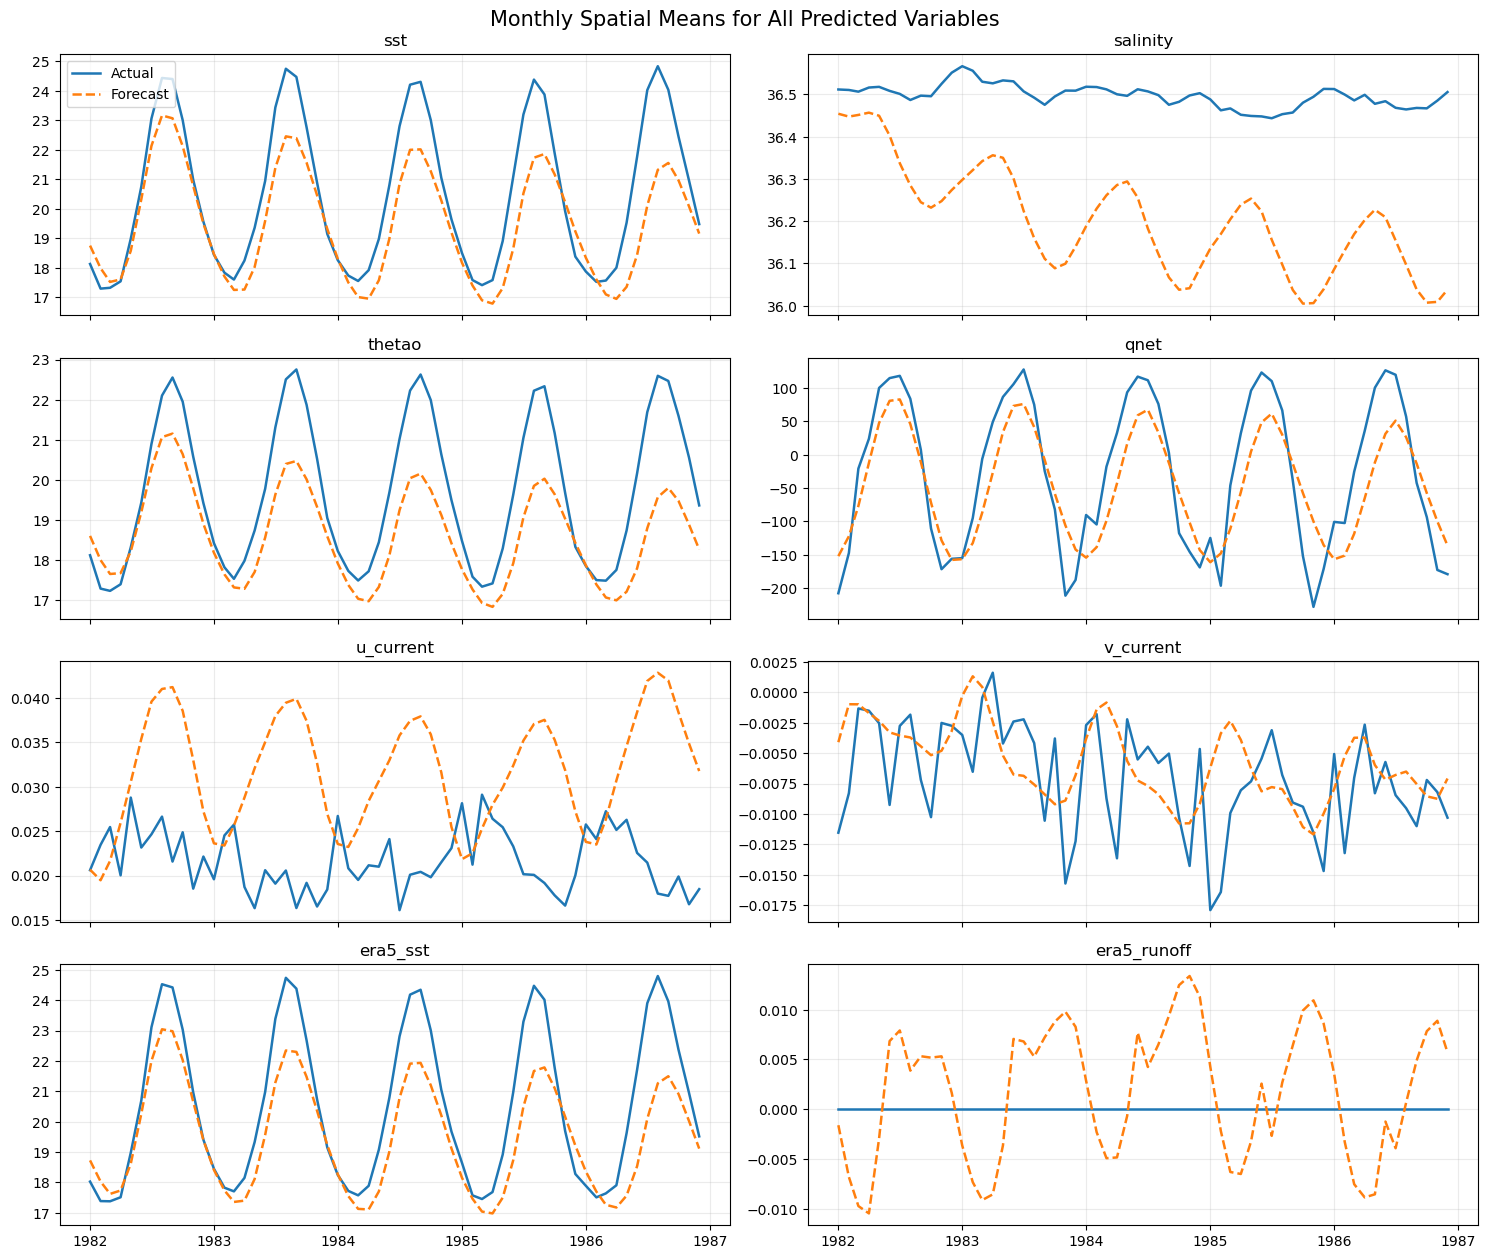

In [29]:
# Feature monthly spatial means

n_features = len(features)
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 3.2 * n_rows),
    sharex=True,
)
axes = np.asarray(axes).ravel()

for feature_index, feature_name in enumerate(features):
    actual_mean = np.nanmean(
        forecast_truth_raw[..., feature_index],
        axis=(1, 2),
    )
    predicted_mean = np.nanmean(
        recursive_forecast[..., feature_index],
        axis=(1, 2),
    )

    ax = axes[feature_index]
    ax.plot(forecast_months, actual_mean, linewidth=1.8, label="Actual")
    ax.plot(
        forecast_months,
        predicted_mean,
        linestyle="--",
        linewidth=1.8,
        label="Forecast",
    )
    ax.set_title(feature_name)
    ax.grid(alpha=0.25)

for ax in axes[n_features:]:
    ax.axis("off")

axes[0].legend()
fig.suptitle("Monthly Spatial Means for All Predicted Variables", fontsize=15)
plt.tight_layout()
plt.show()

In [30]:
# Save tables and ararys

RESULTS_DIR = CACHE_DIR / "ConvLSTM_1982_1986_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

one_step_metrics_df.to_csv(
    RESULTS_DIR / "one_step_metrics_by_feature.csv",
    index=False,
)
recursive_metrics_df.to_csv(
    RESULTS_DIR / "recursive_metrics_by_feature.csv",
    index=False,
)
baseline_comparison_df.to_csv(
    RESULTS_DIR / "persistence_baseline_comparison.csv",
    index=False,
)
forecast_period_metrics_df.to_csv(
    RESULTS_DIR / "sst_metrics_by_forecast_period.csv",
    index=False,
)
yearly_metrics_df.to_csv(
    RESULTS_DIR / "metrics_by_year_and_feature.csv",
    index=False,
)
lead_metrics_df.to_csv(
    RESULTS_DIR / "sst_metrics_by_lead_month.csv",
    index=False,
)
relative_stats_df.to_csv(
    RESULTS_DIR / "sst_relative_difference_by_year.csv",
    index=False,
)
annual_mean_df.to_csv(
    RESULTS_DIR / "sst_annual_box_mean.csv",
    index=False,
)

forecast_da = xr.DataArray(
    recursive_forecast.transpose(0, 3, 1, 2),
    dims=("time", "feature", "lat", "lon"),
    coords={
        "time": forecast_months,
        "feature": features,
        "lat": combined_monthly.lat.values,
        "lon": combined_monthly.lon.values,
    },
    name="forecast",
)

truth_da = xr.DataArray(
    forecast_truth_raw.transpose(0, 3, 1, 2),
    dims=("time", "feature", "lat", "lon"),
    coords=forecast_da.coords,
    name="actual",
)

forecast_dataset = xr.Dataset({
    "forecast": forecast_da,
    "actual": truth_da,
    "error": forecast_da - truth_da,
})

forecast_dataset.to_netcdf(
    RESULTS_DIR / "recursive_forecast_1982_1986.nc",
    engine="h5netcdf",
    encoding={
        name: {
            "zlib": True,
            "complevel": 4,
            "dtype": "float32",
        }
        for name in forecast_dataset.data_vars
    },
)

print("Saved all outputs to:")
print(RESULTS_DIR)

Saved all outputs to:
C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\ConvLSTM_1982_1986_results


In [31]:
# Summary

primary_recursive = recursive_metrics_df.loc[
    recursive_metrics_df["feature"] == PRIMARY_FEATURE
].iloc[0]

primary_one_step = one_step_metrics_df.loc[
    one_step_metrics_df["feature"] == PRIMARY_FEATURE
].iloc[0]

summary = pd.DataFrame([
    {
        "evaluation": "One-step-ahead SST",
        "MAE": primary_one_step["MAE"],
        "RMSE": primary_one_step["RMSE"],
        "R2": primary_one_step["R2"],
        "Bias": primary_one_step["Bias"],
        "Pearson_r": primary_one_step["Pearson_r"],
        "n_valid": primary_one_step["n_valid"],
    },
    {
        "evaluation": "Recursive 5-year SST",
        "MAE": primary_recursive["MAE"],
        "RMSE": primary_recursive["RMSE"],
        "R2": primary_recursive["R2"],
        "Bias": primary_recursive["Bias"],
        "Pearson_r": primary_recursive["Pearson_r"],
        "n_valid": primary_recursive["n_valid"],
    },
])

display(summary)

print(
    f"""
The one-step-ahead SST evaluation achieved an MAE of
{primary_one_step['MAE']:.3f} °C, an RMSE of
{primary_one_step['RMSE']:.3f} °C and an R² of
{primary_one_step['R2']:.3f}.

Across the fully recursive January 1982–December 1986 forecast, the SST
prediction achieved an MAE of {primary_recursive['MAE']:.3f} °C, an RMSE
of {primary_recursive['RMSE']:.3f} °C and an R² of
{primary_recursive['R2']:.3f}. The mean forecast bias was
{primary_recursive['Bias']:.3f} °C.
"""
)

,evaluation,MAE,RMSE,R2,Bias,Pearson_r,n_valid
0,One-step-ahead SST,0.537005,0.773382,0.963047,-0.043679,0.981414,100860
1,Recursive 5-year SST,1.512097,1.996994,0.753617,-1.034654,0.905529,100860



The one-step-ahead SST evaluation achieved an MAE of
0.537 °C, an RMSE of
0.773 °C and an R² of
0.963.

Across the fully recursive January 1982–December 1986 forecast, the SST
prediction achieved an MAE of 1.512 °C, an RMSE
of 1.997 °C and an R² of
0.754. The mean forecast bias was
-1.035 °C.




  ANNUAL BOX-MEAN SST: ACTUAL AND PREDICTED
Actual data shape: (731, 41, 41, 8)
Forecast data shape: (60, 41, 41, 8)


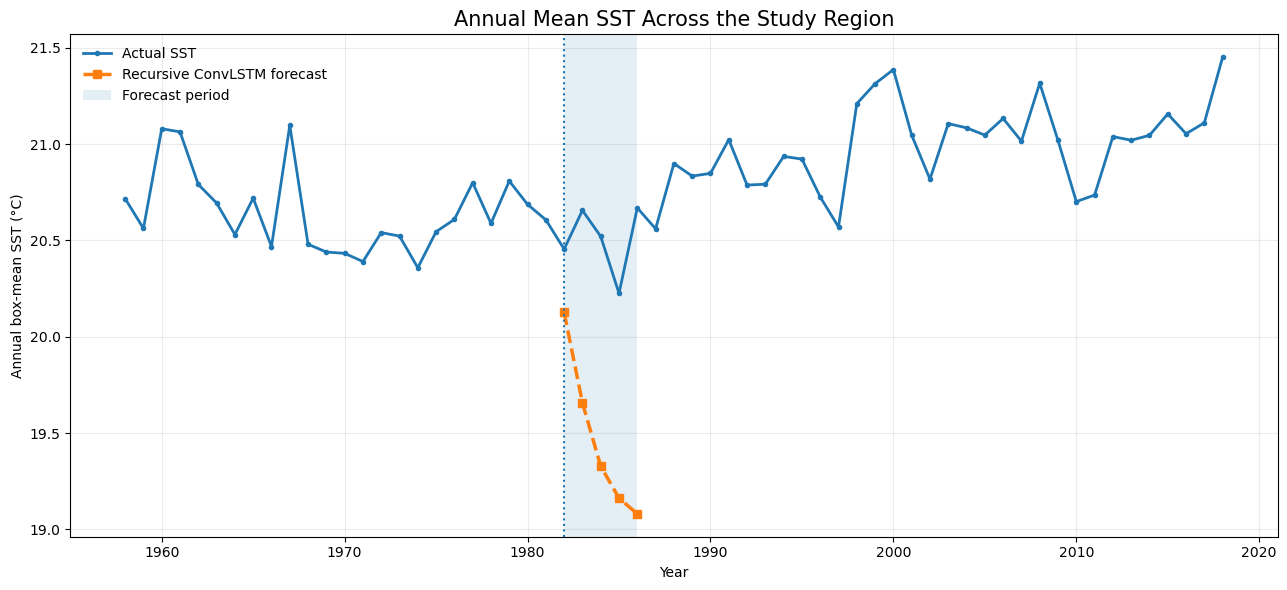

,year,predicted_mean_sst,actual_mean_sst,actual_minus_predicted
0,1982,20.126513,20.454927,0.328415
1,1983,19.656809,20.656385,0.999577
2,1984,19.327951,20.520947,1.192995
3,1985,19.161983,20.225365,1.063381
4,1986,19.080269,20.669170,1.588902


In [34]:
# Annual mean sst

print(
    f"\n{'='*80}\n"
    "  ANNUAL BOX-MEAN SST: ACTUAL AND PREDICTED\n"
    f"{'='*80}"
)

feature_name = "sst"
feature_idx = features.index(feature_name)

all_times = pd.DatetimeIndex(times)
forecast_times = pd.DatetimeIndex(forecast_months)

# Check that the required forecast cell has been run.
if "recursive_forecast" not in globals():
    raise NameError(
        "recursive_forecast does not exist. Run the cell titled "
        "'RECURSIVE FIVE-YEAR FORECAST: JAN 1982 TO DEC 1986' first."
    )

print("Actual data shape:", raw_data.shape)
print("Forecast data shape:", recursive_forecast.shape)

actual_rows = []

for year in np.unique(all_times.year):
    year_mask = all_times.year == year

    actual_values = raw_data[
        year_mask,
        :,
        :,
        feature_idx,
    ]

    if np.isfinite(actual_values).sum() == 0:
        continue

    actual_rows.append({
        "year": int(year),
        "actual_mean_sst": np.nanmean(actual_values),
        "n_months": int(year_mask.sum()),
    })

actual_annual_df = pd.DataFrame(actual_rows)


forecast_rows = []

for year in np.unique(forecast_times.year):
    year_mask = forecast_times.year == year

    predicted_values = recursive_forecast[
        year_mask,
        :,
        :,
        feature_idx,
    ]

    if np.isfinite(predicted_values).sum() == 0:
        continue

    forecast_rows.append({
        "year": int(year),
        "predicted_mean_sst": np.nanmean(predicted_values),
    })

predicted_annual_df = pd.DataFrame(forecast_rows)


fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    actual_annual_df["year"],
    actual_annual_df["actual_mean_sst"],
    linewidth=2,
    marker="o",
    markersize=3,
    label="Actual SST",
)

ax.plot(
    predicted_annual_df["year"],
    predicted_annual_df["predicted_mean_sst"],
    linewidth=2.5,
    linestyle="--",
    marker="s",
    markersize=6,
    label="Recursive ConvLSTM forecast",
)

ax.axvspan(
    FORECAST_START.year,
    FORECAST_END.year,
    alpha=0.12,
    label="Forecast period",
)

ax.axvline(
    FORECAST_START.year,
    linestyle=":",
    linewidth=1.5,
)

ax.set_title(
    "Annual Mean SST Across the Study Region",
    fontsize=15,
)

ax.set_xlabel("Year")
ax.set_ylabel("Annual box-mean SST (°C)")

ax.grid(alpha=0.25)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


annual_comparison_df = predicted_annual_df.merge(
    actual_annual_df[
        ["year", "actual_mean_sst"]
    ],
    on="year",
    how="left",
)

annual_comparison_df["actual_minus_predicted"] = (
    annual_comparison_df["actual_mean_sst"]
    - annual_comparison_df["predicted_mean_sst"]
)

display(annual_comparison_df)


  ANNUAL MEAN RELATIVE DIFFERENCE WITH ERROR ON THE MEAN


,time,year,actual_box_mean_sst,predicted_box_mean_sst,relative_difference
0,1982-01-01,1982,18.129009,18.751587,-0.034342
1,1982-02-01,1982,17.293312,17.986427,-0.040080
2,1982-03-01,1982,17.321173,17.520107,-0.011485
3,1982-04-01,1982,17.539965,17.605331,-0.003727
4,1982-05-01,1982,18.986477,18.575588,0.021641


,year,mean_relative_difference,standard_deviation,standard_error_of_mean,n_months
0,1982,0.012576,0.031324,0.009042,12
1,1983,0.045179,0.036236,0.010460,12
2,1984,0.055205,0.033864,0.009776,12
3,1985,0.048559,0.053364,0.015405,12
4,1986,0.070900,0.063191,0.018242,12


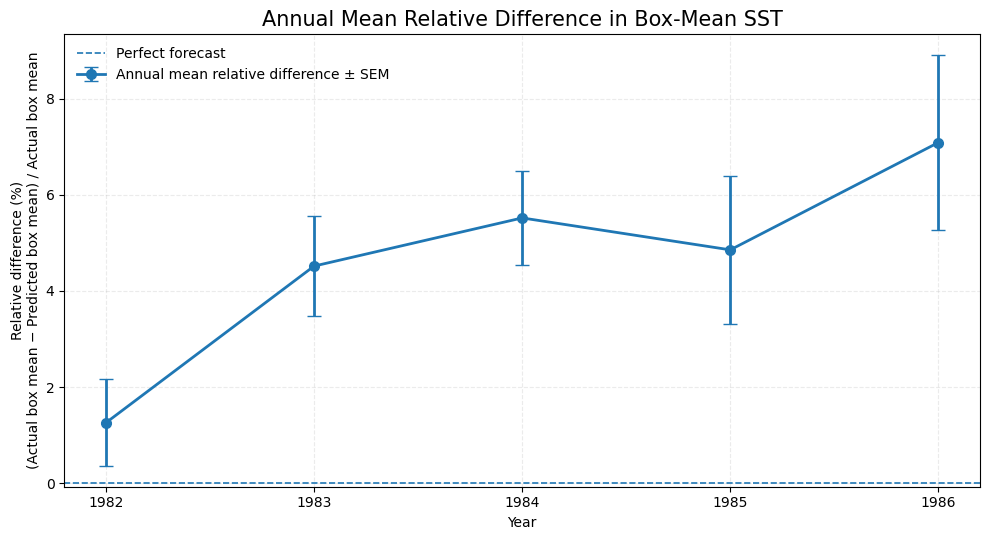

In [37]:
# Annual mean rel differnce in box mean sst
print(
    f"\n{'='*80}\n"
    "  ANNUAL MEAN RELATIVE DIFFERENCE WITH ERROR ON THE MEAN\n"
    f"{'='*80}"
)

feature_name = "sst"
feature_idx = features.index(feature_name)

all_times = pd.DatetimeIndex(times)
forecast_times = pd.DatetimeIndex(forecast_months)

if "recursive_forecast" not in globals():
    raise NameError(
        "recursive_forecast does not exist. Run the recursive "
        "five-year forecast cell first."
    )

# Match forecast months to the actual data
forecast_actual_indices = all_times.get_indexer(
    forecast_times
)

if np.any(forecast_actual_indices < 0):
    missing_dates = forecast_times[
        forecast_actual_indices < 0
    ]

    raise ValueError(
        "Could not match these forecast dates to actual data: "
        + ", ".join(
            date.strftime("%Y-%m")
            for date in missing_dates
        )
    )

actual_sst = raw_data[
    forecast_actual_indices,
    :,
    :,
    feature_idx,
]

predicted_sst = recursive_forecast[
    :,
    :,
    :,
    feature_idx,
]

if actual_sst.shape != predicted_sst.shape:
    raise ValueError(
        "Actual and predicted SST shapes do not match: "
        f"{actual_sst.shape} versus {predicted_sst.shape}"
    )

# Calculate one actual and predicted box mean for every forecast month

monthly_actual_box_mean = np.nanmean(
    actual_sst,
    axis=(1, 2),
)

monthly_predicted_box_mean = np.nanmean(
    predicted_sst,
    axis=(1, 2),
)

# Relative difference between the monthly BOX MEANS
monthly_relative_difference = (
    monthly_actual_box_mean
    - monthly_predicted_box_mean
) / monthly_actual_box_mean

monthly_results_df = pd.DataFrame({
    "time": forecast_times,
    "year": forecast_times.year,
    "actual_box_mean_sst": monthly_actual_box_mean,
    "predicted_box_mean_sst": monthly_predicted_box_mean,
    "relative_difference": monthly_relative_difference,
})

display(monthly_results_df.head())

# Annual mean and standard error across the 12 monthly box-mean values

annual_rows = []

for year, year_df in monthly_results_df.groupby("year"):

    values = year_df[
        "relative_difference"
    ].to_numpy()

    values = values[
        np.isfinite(values)
    ]

    n_months = len(values)

    if n_months == 0:
        continue

    annual_mean = np.mean(values)

    if n_months > 1:
        annual_std = np.std(
            values,
            ddof=1,
        )

        annual_sem = (
            annual_std
            / np.sqrt(n_months)
        )

    else:
        annual_std = np.nan
        annual_sem = np.nan

    annual_rows.append({
        "year": int(year),
        "mean_relative_difference": annual_mean,
        "standard_deviation": annual_std,
        "standard_error_of_mean": annual_sem,
        "n_months": n_months,
    })

annual_relative_difference_df = pd.DataFrame(
    annual_rows
)

display(annual_relative_difference_df)


years_plot = annual_relative_difference_df[
    "year"
].to_numpy()

mean_percent = (
    annual_relative_difference_df[
        "mean_relative_difference"
    ].to_numpy()
    * 100
)

sem_percent = (
    annual_relative_difference_df[
        "standard_error_of_mean"
    ].to_numpy()
    * 100
)

fig, ax = plt.subplots(
    figsize=(10, 5.5)
)

ax.errorbar(
    years_plot,
    mean_percent,
    yerr=sem_percent,
    marker="o",
    markersize=7,
    linewidth=2,
    capsize=5,
    label="Annual mean relative difference ± SEM",
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.2,
    label="Perfect forecast",
)

ax.set_title(
    "Annual Mean Relative Difference in Box-Mean SST",
    fontsize=15,
)

ax.set_xlabel("Year")

ax.set_ylabel(
    "Relative difference (%)\n"
    "(Actual box mean − Predicted box mean) / Actual box mean"
)

ax.set_xticks(years_plot)

ax.grid(
    alpha=0.25,
    linestyle="--",
)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()


  ANNUAL RELATIVE-DIFFERENCE HISTOGRAMS | SST
Actual SST shape: (60, 41, 41)
Predicted SST shape: (60, 41, 41)
1982: 12 × 41 × 41 = 20,172 possible entries; 20,172 valid entries
1983: 12 × 41 × 41 = 20,172 possible entries; 20,172 valid entries
1984: 12 × 41 × 41 = 20,172 possible entries; 20,172 valid entries
1985: 12 × 41 × 41 = 20,172 possible entries; 20,172 valid entries
1986: 12 × 41 × 41 = 20,172 possible entries; 20,172 valid entries


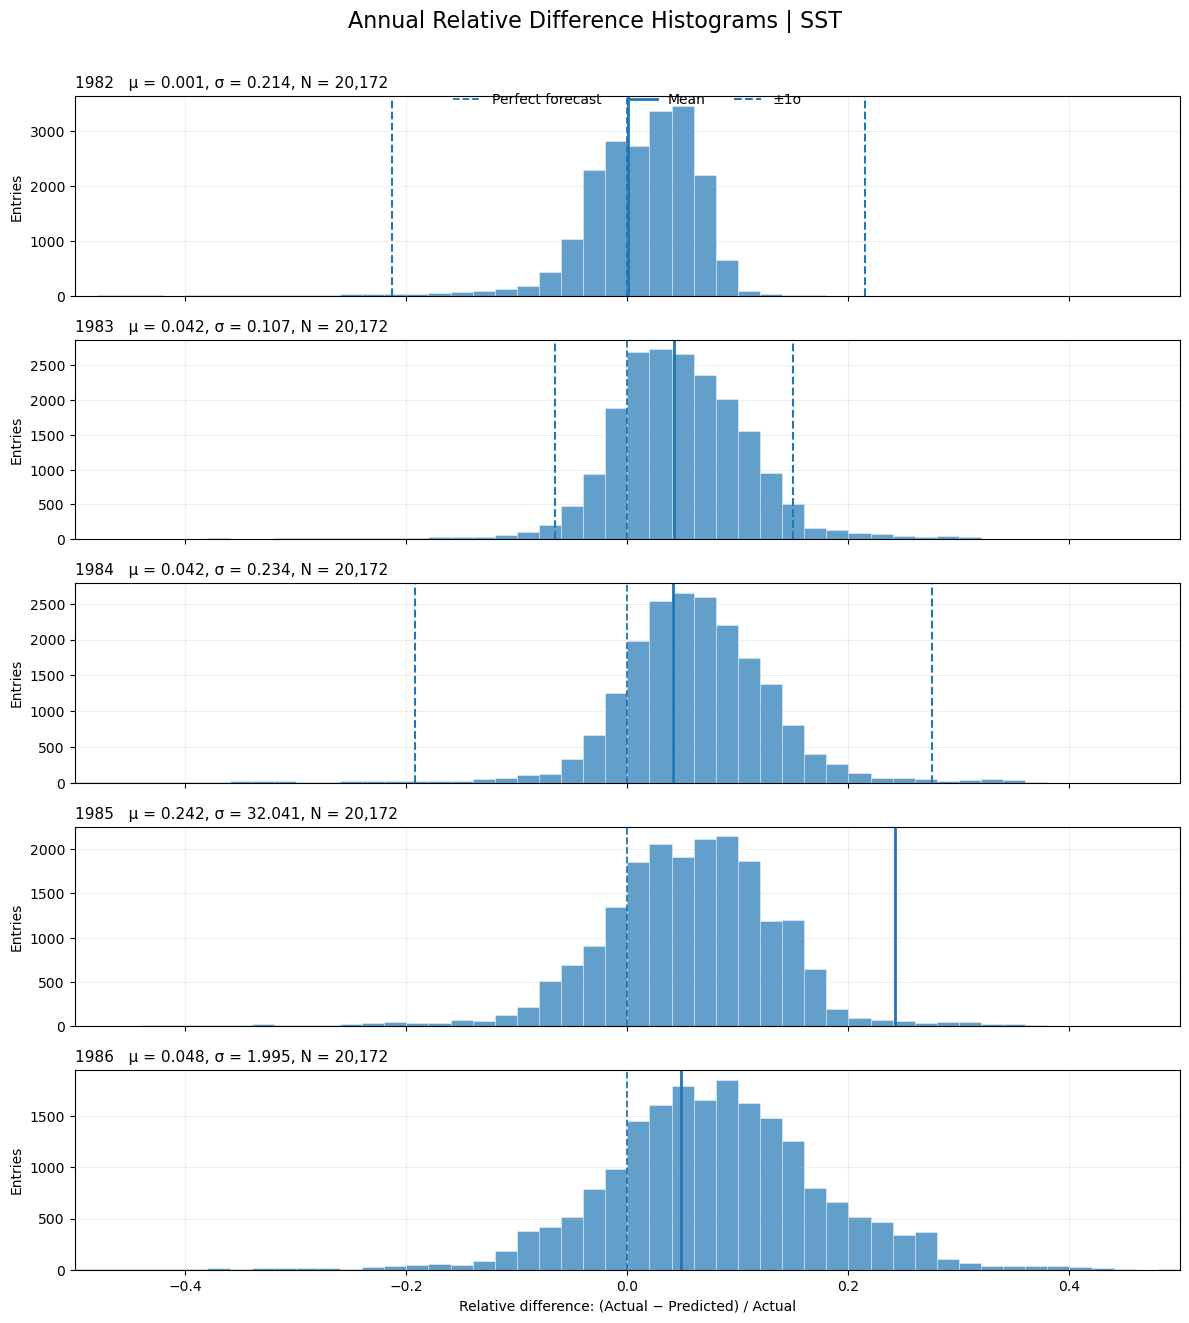

,year,mean,standard_deviation,standard_error_of_mean,n_entries
0,1982,0.001003,0.214327,0.001509,20172
1,1983,0.042344,0.107452,0.000757,20172
2,1984,0.041705,0.233690,0.001645,20172
3,1985,0.241806,32.040574,0.225593,20172
4,1986,0.048205,1.995305,0.014049,20172


In [40]:
# Annual relative difference histograms
# Each histogram contains every monthly grid-cell relative difference:
# 12 months × 41 latitudes × 41 longitudes = 20,172 entries per year
# Relative difference = Actual - Predicted) / Actual

print(
    f"\n{'='*80}\n"
    "  ANNUAL RELATIVE-DIFFERENCE HISTOGRAMS | SST\n"
    f"{'='*80}"
)

feature_name = "sst"
feature_idx = features.index(feature_name)

all_times = pd.DatetimeIndex(times)
forecast_times = pd.DatetimeIndex(forecast_months)

if "recursive_forecast" not in globals():
    raise NameError(
        "recursive_forecast does not exist. "
        "Run the recursive five-year forecast cell first."
    )

forecast_actual_indices = all_times.get_indexer(
    forecast_times
)

if np.any(forecast_actual_indices < 0):
    missing_dates = forecast_times[
        forecast_actual_indices < 0
    ]

    raise ValueError(
        "Could not match these forecast dates to actual data: "
        + ", ".join(
            date.strftime("%Y-%m")
            for date in missing_dates
        )
    )

actual_sst = raw_data[
    forecast_actual_indices,
    :,
    :,
    feature_idx,
]

predicted_sst = recursive_forecast[
    :,
    :,
    :,
    feature_idx,
]

if actual_sst.shape != predicted_sst.shape:
    raise ValueError(
        "Actual and predicted SST shapes do not match: "
        f"{actual_sst.shape} versus {predicted_sst.shape}"
    )

print("Actual SST shape:", actual_sst.shape)
print("Predicted SST shape:", predicted_sst.shape)


minimum_absolute_sst = 1e-6

monthly_relative_difference = np.full(
    actual_sst.shape,
    np.nan,
    dtype=np.float64,
)

valid = (
    np.isfinite(actual_sst)
    & np.isfinite(predicted_sst)
    & (np.abs(actual_sst) > minimum_absolute_sst)
)

monthly_relative_difference[valid] = (
    actual_sst[valid]
    - predicted_sst[valid]
) / actual_sst[valid]

forecast_years = np.unique(
    forecast_times.year
)

annual_values = {}

for year in forecast_years:
    year_mask = forecast_times.year == year

    year_array = monthly_relative_difference[
        year_mask,
        :,
        :,
    ]

    n_months = year_array.shape[0]
    n_lat = year_array.shape[1]
    n_lon = year_array.shape[2]

    expected_entries = (
        n_months
        * n_lat
        * n_lon
    )

    values = year_array.ravel()

    # Remove only invalid values.
    values = values[
        np.isfinite(values)
    ]

    annual_values[int(year)] = values

    print(
        f"{int(year)}: "
        f"{n_months} × {n_lat} × {n_lon} = "
        f"{expected_entries:,} possible entries; "
        f"{values.size:,} valid entries"
    )


x_min = -0.5
x_max = 0.5

n_bins = 50

shared_bins = np.linspace(
    x_min,
    x_max,
    n_bins + 1,
)


n_years = len(forecast_years)

fig, axes = plt.subplots(
    nrows=n_years,
    ncols=1,
    figsize=(12, 2.65 * n_years),
    sharex=True,
)

if n_years == 1:
    axes = [axes]

fig.suptitle(
    "Annual Relative Difference Histograms | SST",
    fontsize=16,
    y=0.995,
)

summary_rows = []

for plot_index, year in enumerate(
    forecast_years
):
    ax = axes[plot_index]

    values = annual_values[
        int(year)
    ]

    mean_error = np.mean(
        values
    )

    standard_deviation = np.std(
        values,
        ddof=1,
    )

    standard_error = (
        standard_deviation
        / np.sqrt(values.size)
    )

    summary_rows.append({
        "year": int(year),
        "mean": mean_error,
        "standard_deviation": standard_deviation,
        "standard_error_of_mean": standard_error,
        "n_entries": values.size,
    })

    ax.hist(
        values,
        bins=shared_bins,
        alpha=0.70,
        edgecolor="white",
        linewidth=0.4,
    )

    # Perfect forecast.
    ax.axvline(
        0,
        linestyle="--",
        linewidth=1.3,
        label="Perfect forecast"
        if plot_index == 0
        else None,
    )

    # Distribution mean.
    ax.axvline(
        mean_error,
        linewidth=2,
        label="Mean"
        if plot_index == 0
        else None,
    )

    # Mean ± one standard deviation.
    ax.axvline(
        mean_error - standard_deviation,
        linestyle="--",
        linewidth=1.5,
        label="±1σ"
        if plot_index == 0
        else None,
    )

    ax.axvline(
        mean_error + standard_deviation,
        linestyle="--",
        linewidth=1.5,
    )

    ax.set_xlim(
        x_min,
        x_max,
    )

    ax.set_ylabel("Entries")

    ax.set_title(
        (
            f"{int(year)}   "
            f"μ = {mean_error:.3f}, "
            f"σ = {standard_deviation:.3f}, "
            f"N = {values.size:,}"
        ),
        loc="left",
        fontsize=11,
        pad=6,
    )

    ax.grid(
        alpha=0.20,
    )

axes[0].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=3,
    frameon=False,
)

axes[-1].set_xlabel(
    "Relative difference: (Actual − Predicted) / Actual"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.985]
)

plt.show()

# -------------------------------------------------------------------------
# Summary table
# -------------------------------------------------------------------------

annual_histogram_summary_df = pd.DataFrame(
    summary_rows
)

display(
    annual_histogram_summary_df
)